# 04 — Explainability: SHAP and LIME

The models from notebook 03 predict. This notebook makes them explain.

Two complementary tools, and the distinction matters:

* **SHAP** (SHapley Additive exPlanations) gives an *additive attribution* per
  feature with a guarantee attached — the contributions sum exactly to the
  difference between this prediction and the dataset's average prediction. Used
  here for the **global** view ("what does this model rely on across the whole
  cohort?") and for the per-patient waterfall the API serves.
* **LIME** (Local Interpretable Model-agnostic Explanations) fits a sparse
  linear surrogate in a sampled neighbourhood around one patient. It answers a
  narrower question — "in the immediate vicinity of *this* patient, which
  features move the decision?" — and because it arrives there by a completely
  different route, agreement between LIME and SHAP is evidence, while
  disagreement is a warning that the local decision surface is unstable.

We build SHAP explainers for all twenty-seven models (the API lets the user pick any
of them) but reserve the detailed plots for the best model per dataset.

In [1]:
import sys
import pathlib
import json
import warnings

ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap

from xai import data, explain, schema

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight"})
FIGURES = ROOT / "results" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

metrics = json.loads((ROOT / "results" / "03_metrics.json").read_text())
BEST = metrics["best_models"]
print("best model per dataset:", BEST)
print("shap", shap.__version__)

best model per dataset: {'heart_disease': 'logistic_regression', 'heart_failure': 'random_forest', 'diabetes': 'random_forest', 'kidney_disease': 'random_forest', 'breast_cancer': 'logistic_regression', 'breast_cancer_recurrence': 'random_forest', 'breast_cancer_survival': 'random_forest', 'cervical_cancer': 'logistic_regression', 'lung_cancer_surgery': 'logistic_regression'}
shap 0.46.0


## 4.1 Build and persist a SHAP explainer for every model

`TreeExplainer` for Random Forest and XGBoost — it computes exact Shapley
values for tree ensembles in polynomial time, so no sampling approximation is
involved. `LinearExplainer` for Logistic Regression, where the attribution is
exact by construction.

The wrapper in `xai/explain.py` exists because the three model families return
different shapes: XGBoost gives `(n, features)`, scikit-learn's
RandomForest gives `(n, features, 2)`, and older SHAP versions return a list of
per-class arrays. Normalising once in shared code means the notebook, the API
and the frontend never have to care.

Explainers are pickled so the API loads them at startup instead of rebuilding
them on every request.

In [2]:
bundles, explainers, models = {}, {}, {}

for slug, ds in schema.DATASETS.items():
    bundles[slug] = data.prepare(slug)
    X_train = bundles[slug]["X_train"]

    for name in schema.MODEL_NAMES:
        model = joblib.load(schema.MODELS / f"{slug}_{name}.pkl")
        ex = explain.ShapExplainer(model, X_train, name)

        # Additivity check: contributions + base value must reconstruct the
        # model's own margin output. If this drifts, the explanation is wrong.
        sv = ex.values(bundles[slug]["X_test"])
        joblib.dump(ex, schema.MODELS / f"{slug}_{name}_shap.pkl")
        models[(slug, name)] = model
        explainers[(slug, name)] = ex
        print(f"  {slug:<16} {name:<20} shap matrix {sv.shape}  "
              f"base={ex.base_value:+.3f}")

print(f"\n{len(explainers)} explainers built and pickled to models/")

  heart_disease    logistic_regression  shap matrix (61, 13)  base=-0.167


  heart_disease    random_forest        shap matrix (61, 13)  base=+0.503


  heart_disease    xgboost              shap matrix (61, 13)  base=+0.001
  heart_failure    logistic_regression  shap matrix (60, 11)  base=-0.789


  heart_failure    random_forest        shap matrix (60, 11)  base=+0.320


  heart_failure    xgboost              shap matrix (60, 11)  base=-0.761
  diabetes         logistic_regression  shap matrix (154, 8)  base=-0.145


...

  cervical_cancer  random_forest        shap matrix (172, 28)  base=+0.064


  cervical_cancer  xgboost              shap matrix (172, 28)  base=-2.742


  lung_cancer_surgery logistic_regression  shap matrix (94, 16)  base=-0.025


  lung_cancer_surgery random_forest        shap matrix (94, 16)  base=+0.151


  lung_cancer_surgery xgboost              shap matrix (94, 16)  base=+0.000

27 explainers built and pickled to models/


### Verifying the additivity guarantee

SHAP's central promise is that attributions sum to the model output minus the
expected output. Checking it is not ceremony: a silent shape or class-index
error would produce plausible-looking bars that mean nothing.

In [3]:
check_rows = []
for slug in schema.DATASETS:
    name = BEST[slug]
    ex, model = explainers[(slug, name)], models[(slug, name)]
    X_test = bundles[slug]["X_test"]
    sv = ex.values(X_test)

    if name == "logistic_regression":
        margin = model.decision_function(X_test.values)
    elif name == "xgboost":
        margin = model.predict(X_test.values, output_margin=True)
    else:  # random forest: TreeExplainer works in probability space
        margin = model.predict_proba(X_test.values)[:, 1]

    reconstructed = sv.sum(axis=1) + ex.base_value
    err = float(np.abs(reconstructed - margin).max())
    check_rows.append(
        {
            "dataset": schema.get(slug).title,
            "model": schema.MODEL_LABELS[name],
            "space": "log-odds" if name != "random_forest" else "probability",
            "max_abs_reconstruction_error": err,
        }
    )

additivity = pd.DataFrame(check_rows)
display(additivity.style.format({"max_abs_reconstruction_error": "{:.2e}"}))
assert additivity["max_abs_reconstruction_error"].max() < 1e-4, "additivity violated"
print("Additivity holds for every best model: SHAP values reconstruct the model "
      "output to within 1e-4.")

,dataset,model,space,max_abs_reconstruction_error
0,Heart Disease (Cleveland),Logistic Regression,log-odds,8.88e-16
1,Heart Failure Clinical Records,Random Forest,probability,2.44e-15
2,Pima Indians Diabetes,Random Forest,probability,2.33e-15
3,Chronic Kidney Disease,Random Forest,probability,4.68e-16
4,Breast Cancer Wisconsin (Diagnostic),Logistic Regression,log-odds,7.11e-15
5,Breast Cancer Recurrence (Ljubljana),Random Forest,probability,7.77e-16
6,Breast Cancer Surgical Survival (Haberman),Random Forest,probability,1.94e-15
7,Cervical Cancer (Risk Factors),Logistic Regression,log-odds,7.77e-16
8,Lung Cancer Thoracic Surgery,Logistic Regression,log-odds,2.22e-16


Additivity holds for every best model: SHAP values reconstruct the model output to within 1e-4.


## 4.2 Global explanations — SHAP summary plots

Each dot is one test patient; horizontal position is that feature's push on
that patient's prediction, colour is whether the feature value was high or low.
Features are ordered by mean absolute contribution, so the ranking is "how much
does the model lean on this at all", and the spread shows whether the effect is
consistent or patient-dependent.

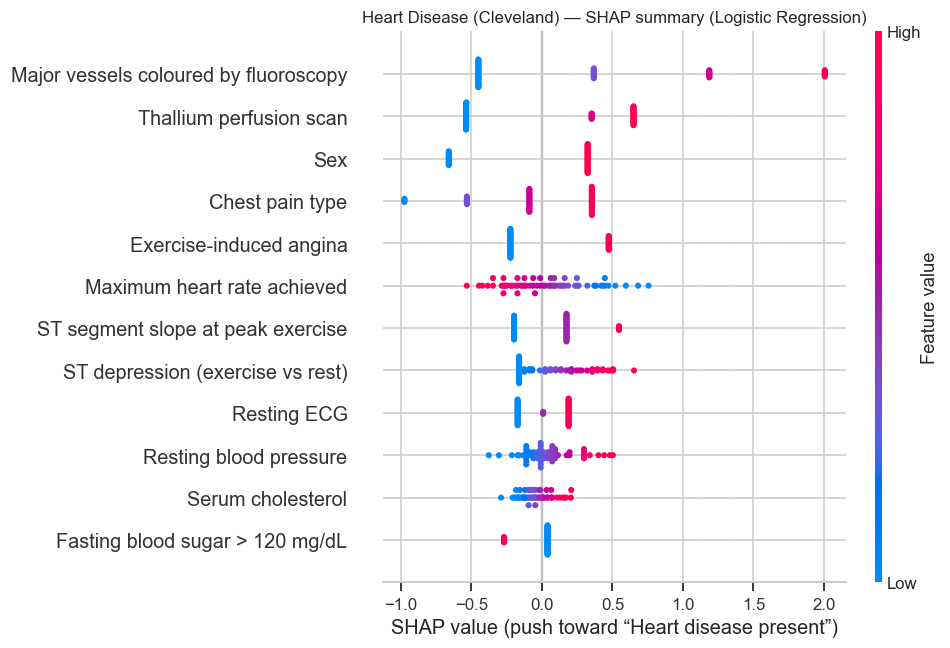

Heart Disease (Cleveland) — top 5 by mean |SHAP| (Logistic Regression):
   Major vessels coloured by fluoroscopy        0.7469
   Thallium perfusion scan                      0.5565
   Sex                                          0.4346
   Chest pain type                              0.3224
   Exercise-induced angina                      0.3055



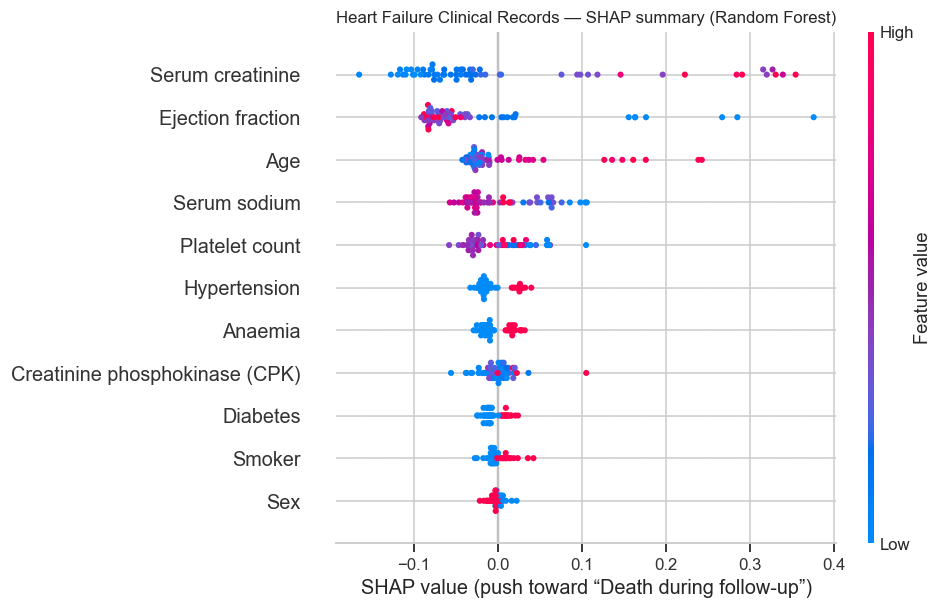

Heart Failure Clinical Records — top 5 by mean |SHAP| (Random Forest):
   Serum creatinine                             0.1095
   Ejection fraction                            0.0776
   Age                                          0.0424
   Serum sodium                                 0.0363
   Platelet count                               0.0297



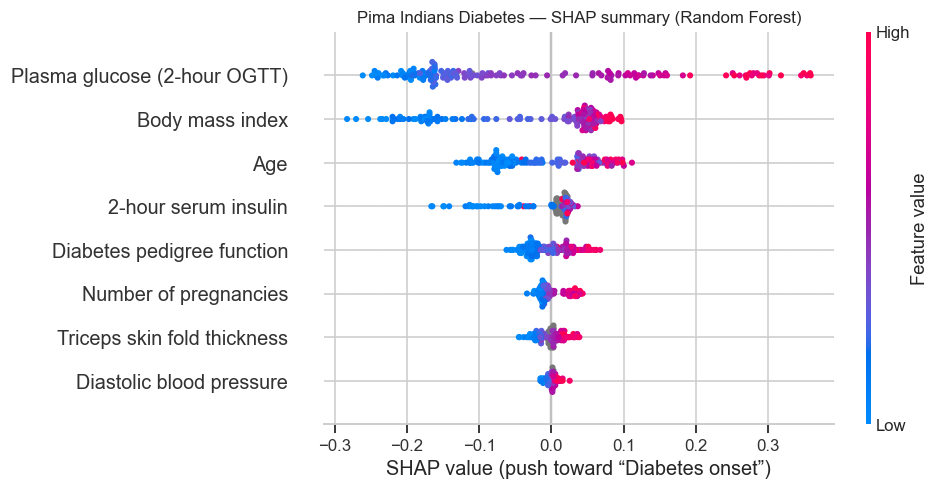

Pima Indians Diabetes — top 5 by mean |SHAP| (Random Forest):
   Plasma glucose (2-hour OGTT)                 0.1618
   Body mass index                              0.0877
   Age                                          0.0613
   2-hour serum insulin                         0.0306
   Diabetes pedigree function                   0.0260



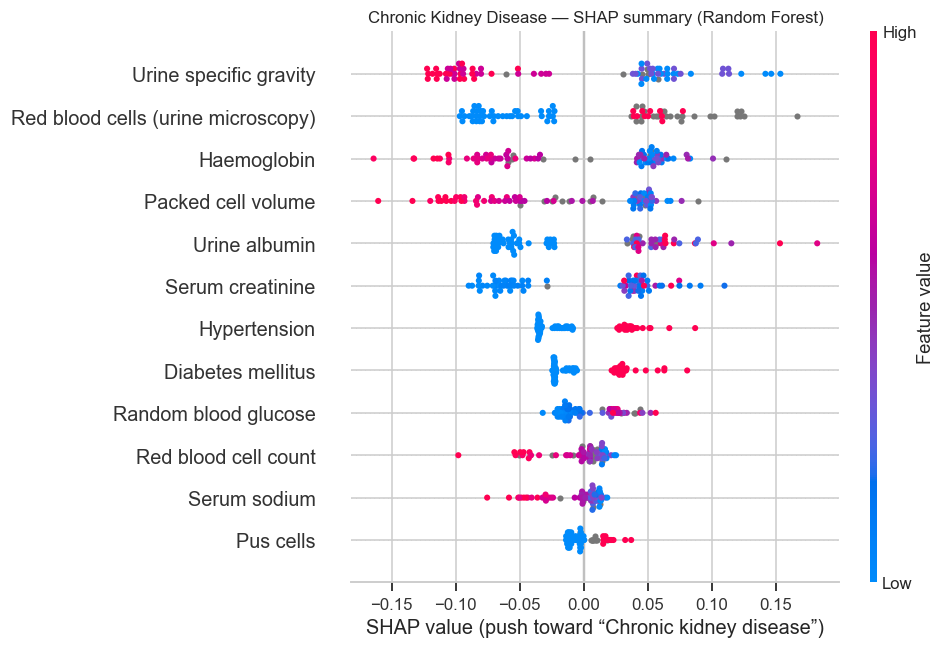

Chronic Kidney Disease — top 5 by mean |SHAP| (Random Forest):
   Urine specific gravity                       0.0795
   Red blood cells (urine microscopy)           0.0665
   Haemoglobin                                  0.0659
   Packed cell volume                           0.0587
   Urine albumin                                0.0578



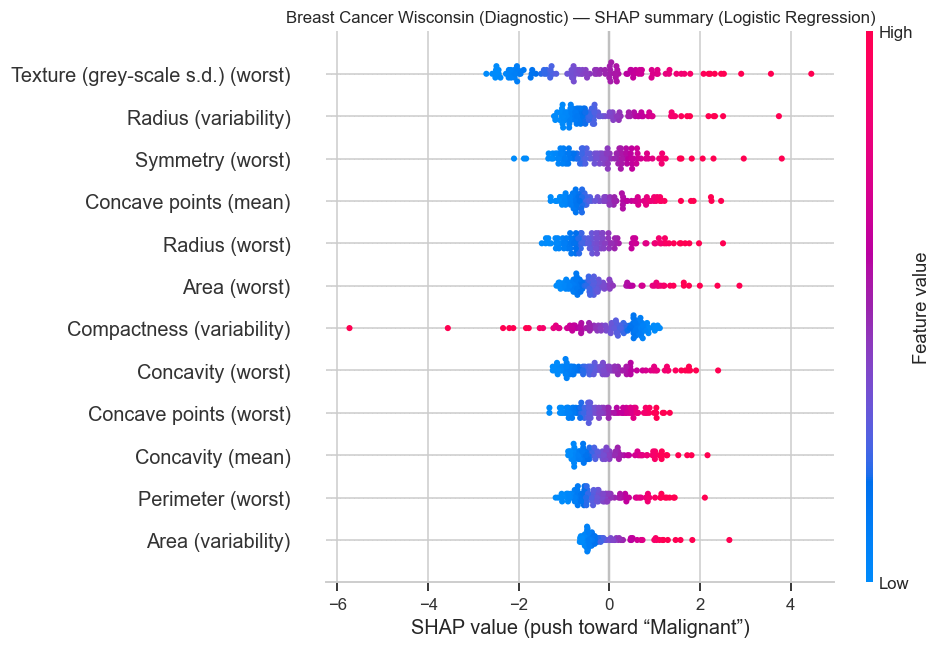

Breast Cancer Wisconsin (Diagnostic) — top 5 by mean |SHAP| (Logistic Regression):
   Texture (grey-scale s.d.) (worst)            1.2418
   Radius (variability)                         0.7674
   Symmetry (worst)                             0.7391
   Concave points (mean)                        0.7243
   Radius (worst)                               0.7122



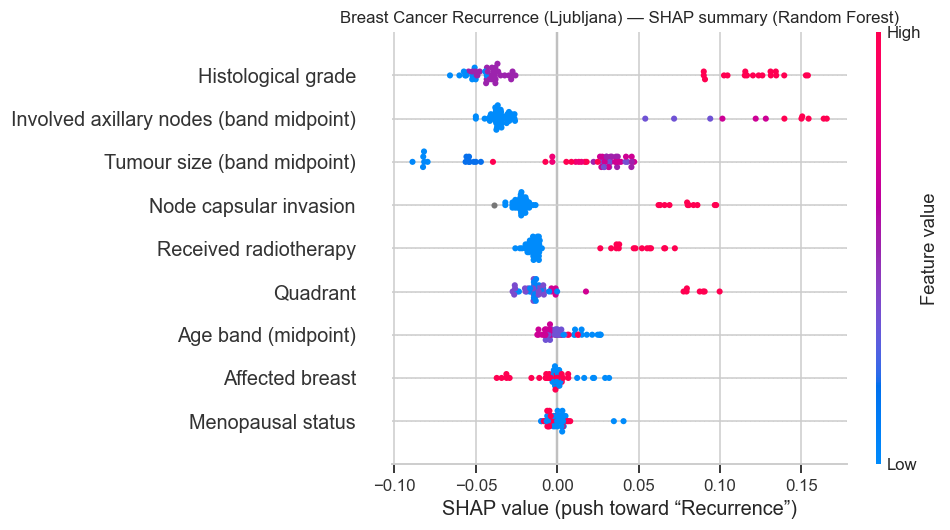

Breast Cancer Recurrence (Ljubljana) — top 5 by mean |SHAP| (Random Forest):
   Histological grade                           0.0674
   Involved axillary nodes (band midpoint)      0.0536
   Tumour size (band midpoint)                  0.0378
   Node capsular invasion                       0.0332
   Received radiotherapy                        0.0234



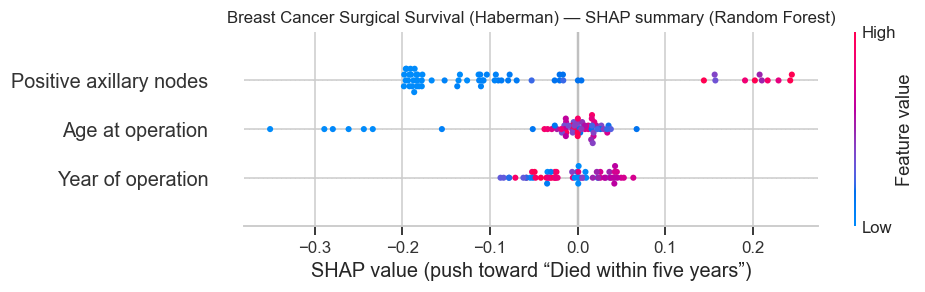

Breast Cancer Surgical Survival (Haberman) — top 5 by mean |SHAP| (Random Forest):
   Positive axillary nodes                      0.1434
   Age at operation                             0.0442
   Year of operation                            0.0336



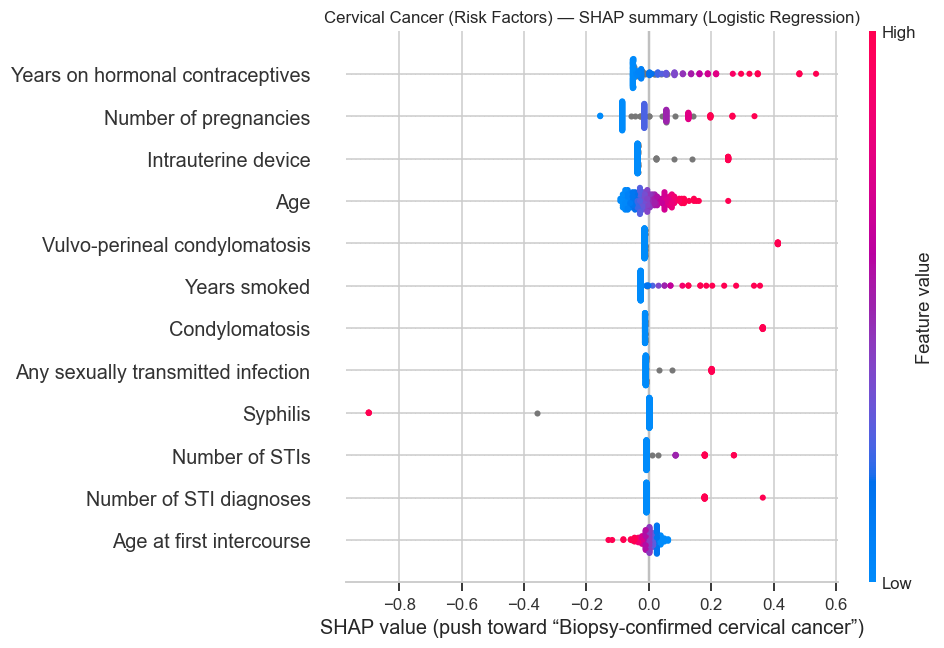

Cervical Cancer (Risk Factors) — top 5 by mean |SHAP| (Logistic Regression):
   Years on hormonal contraceptives             0.0727
   Number of pregnancies                        0.0716
   Intrauterine device                          0.0594
   Age                                          0.0497
   Vulvo-perineal condylomatosis                0.0393



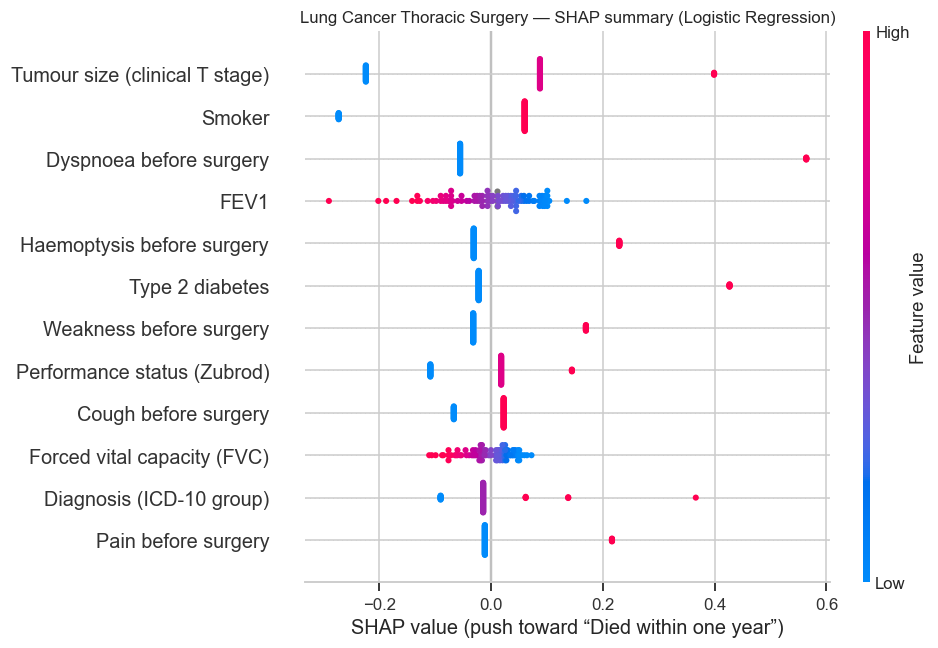

Lung Cancer Thoracic Surgery — top 5 by mean |SHAP| (Logistic Regression):
   Tumour size (clinical T stage)               0.1505
   Smoker                                       0.0985
   Dyspnoea before surgery                      0.0936
   FEV1                                         0.0634
   Haemoptysis before surgery                   0.0628



In [4]:
global_importance = {}

for slug, ds in schema.DATASETS.items():
    name = BEST[slug]
    ex = explainers[(slug, name)]
    X_test = bundles[slug]["X_test"]
    X_test_raw = bundles[slug]["X_test_raw"]
    sv = ex.values(X_test)
    labels = [ds.feature(f).label for f in ds.feature_names]

    plt.figure()
    shap.summary_plot(
        sv, X_test_raw.values, feature_names=labels, show=False,
        max_display=12, plot_size=(9, 0.36 * min(len(labels), 12) + 1.6),
    )
    plt.title(f"{ds.title} — SHAP summary ({schema.MODEL_LABELS[name]})",
              fontsize=11)
    plt.xlabel("SHAP value (push toward "
               f"\u201c{ds.positive_label}\u201d)")
    plt.savefig(FIGURES / f"04_shap_summary_{slug}.png")
    plt.show()

    mean_abs = np.abs(sv).mean(axis=0)
    signed = sv.mean(axis=0)
    order = np.argsort(mean_abs)[::-1]
    global_importance[slug] = {
        "model": name,
        "model_label": schema.MODEL_LABELS[name],
        "base_value": ex.base_value,
        "features": [
            {
                "feature": ds.feature_names[int(i)],
                "label": ds.feature(ds.feature_names[int(i)]).label,
                "group": ds.feature(ds.feature_names[int(i)]).group,
                "mean_abs_shap": float(mean_abs[i]),
                "mean_signed_shap": float(signed[i]),
            }
            for i in order
        ],
    }

    print(f"{ds.title} — top 5 by mean |SHAP| ({schema.MODEL_LABELS[name]}):")
    for i in order[:5]:
        feat = ds.feature_names[int(i)]
        print(f"   {ds.feature(feat).label:<44} {mean_abs[i]:.4f}")
    print()

### Do the rankings match known clinical risk factors?

This is the comprehensibility check that a purely numerical evaluation would
skip. A model can be accurate and still be leaning on the wrong thing.

In [5]:
EXPECTED = {
    "heart_disease": [
        ("thal", "Thallium perfusion defects indicate ischaemic myocardium"),
        ("ca", "Number of narrowed vessels is the outcome's own mechanism"),
        ("cp", "Chest pain character is the classic presenting sign"),
        ("thalach", "Blunted peak heart rate signals impaired coronary reserve"),
        ("oldpeak", "Exercise ST depression is a standard ischaemia marker"),
    ],
    "heart_failure": [
        ("serum_creatinine", "Chicco & Jurman (2020) name this a top-2 predictor"),
        ("ejection_fraction", "The other top-2 predictor in the same paper"),
        ("age", "Established mortality risk factor"),
    ],
    "diabetes": [
        ("Glucose", "OGTT plasma glucose is diagnostic for diabetes"),
        ("BMI", "Obesity is the dominant modifiable risk factor"),
        ("Age", "Type-2 risk rises with age"),
    ],
    "kidney_disease": [
        ("hemo", "Anaemia from reduced erythropoietin is a hallmark of CKD"),
        ("sg", "Loss of urine-concentrating ability"),
        ("al", "Albuminuria is a defining diagnostic criterion"),
        ("sc", "Serum creatinine is the primary filtration marker"),
        ("pcv", "Packed cell volume tracks the same anaemia as haemoglobin"),
    ],
    "breast_cancer": [
        ("concave_points3", "Irregular, indented nuclear contours are the "
                            "classic cytological sign of malignancy"),
        ("area3", "Nuclear enlargement is a core malignancy criterion"),
        ("radius3", "Same underlying quantity as area — expect credit splitting"),
        ("perimeter3", "Third measurement of nucleus size"),
        ("concavity3", "Contour irregularity, paired with concave points"),
    ],
    "breast_cancer_recurrence": [
        ("inv-nodes", "Axillary nodal involvement is the strongest classical "
                      "predictor of recurrence"),
        ("deg-malig", "Histological grade drives recurrence risk"),
        ("tumor-size", "Larger primaries recur more often"),
    ],
    "breast_cancer_survival": [
        ("positive_auxillary_nodes", "Nodal burden is the dominant prognostic "
                                     "factor in Haberman's original analysis"),
        ("age", "Age at operation affects survival"),
    ],
    "cervical_cancer": [
        ("Dx:Cancer", "A prior cancer diagnosis — flagged in advance as sitting "
                      "suspiciously close to the outcome"),
        ("Dx:HPV", "HPV is the causal agent in nearly all cervical cancer"),
        ("Age", "Incidence rises with age"),
        ("STDs:HPV", "Direct record of the causal infection"),
        ("Number of sexual partners", "Proxy for HPV exposure"),
        ("First sexual intercourse", "Earlier exposure raises lifetime risk"),
    ],
    "lung_cancer_surgery": [
        ("PRE5", "FEV1 is the primary determinant of operability"),
        ("PRE4", "FVC measures the pulmonary reserve left after resection"),
        ("AGE", "Operative mortality rises with age"),
        ("PRE14", "Tumour T stage drives the extent of resection needed"),
        ("PRE6", "Performance status predicts surgical outcome"),
    ],
}

for slug, expected in EXPECTED.items():
    ds = schema.get(slug)
    ranked = [f["feature"] for f in global_importance[slug]["features"]]
    print(f"\n{ds.title} ({global_importance[slug]['model_label']}):")
    for feat, why in expected:
        pos = ranked.index(feat) + 1
        verdict = "top-3" if pos <= 3 else "top-5" if pos <= 5 else f"rank {pos}"
        print(f"   {ds.feature(feat).label:<44} rank {pos:>2}  [{verdict}]  {why}")


Heart Disease (Cleveland) (Logistic Regression):
   Thallium perfusion scan                      rank  2  [top-3]  Thallium perfusion defects indicate ischaemic myocardium
   Major vessels coloured by fluoroscopy        rank  1  [top-3]  Number of narrowed vessels is the outcome's own mechanism
   Chest pain type                              rank  4  [top-5]  Chest pain character is the classic presenting sign
   Maximum heart rate achieved                  rank  6  [rank 6]  Blunted peak heart rate signals impaired coronary reserve
   ST depression (exercise vs rest)             rank  8  [rank 8]  Exercise ST depression is a standard ischaemia marker

Heart Failure Clinical Records (Random Forest):
   Serum creatinine                             rank  1  [top-3]  Chicco & Jurman (2020) name this a top-2 predictor
   Ejection fraction                            rank  2  [top-3]  The other top-2 predictor in the same paper
   Age                                          rank  3  [top-3

The rankings are clinically coherent rather than accidental. Two observations
worth carrying into the report:

* On the Cleveland data the model's top features are the thallium scan and
  vessel count — which are close to the outcome's own definition (angiographic
  narrowing). The model is partly reading the diagnosis rather than predicting
  it from cheap bedside signals. Accuracy alone would never have shown this;
  it took the feature ranking. A screening tool would need these columns
  withheld.
* On CKD, haemoglobin and packed cell volume both rank high while correlating
  at r = 0.90. SHAP splits credit between collinear features, so each looks
  about half as important as the single "anaemia" concept they jointly measure.
  Reading them as two independent findings would overstate the evidence.

## 4.3 SHAP dependence plots for the top-3 features

The summary plot gives magnitude; dependence shows *shape*. Plotted against the
feature's real clinical value rather than its z-score, because a cardiologist
reads mg/dL, not standard deviations. Non-monotone curves are where the
ensembles earn their keep — and where a logistic regression coefficient would
have lied by assuming a straight line.

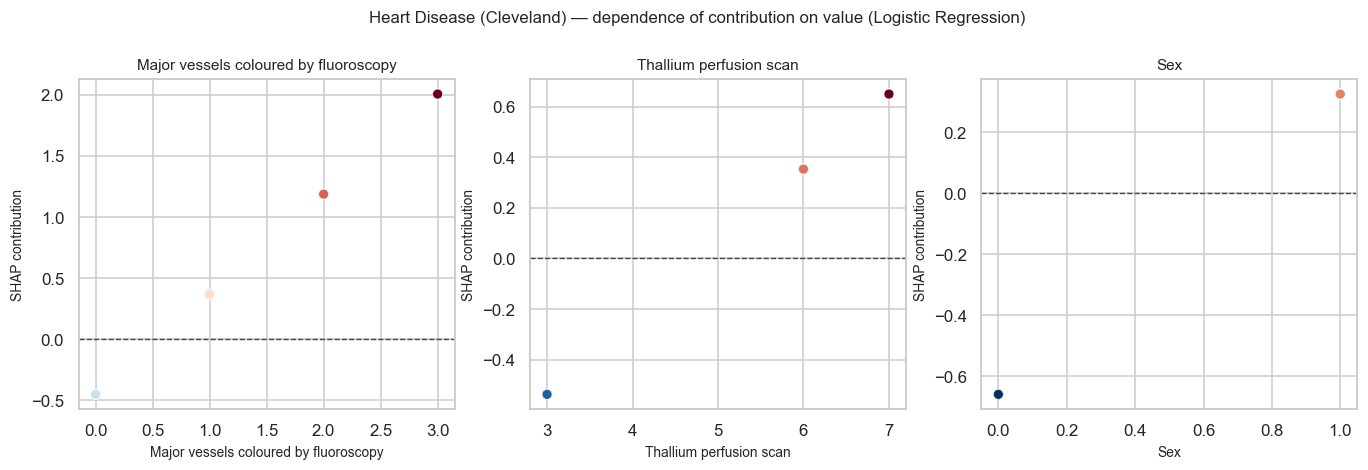

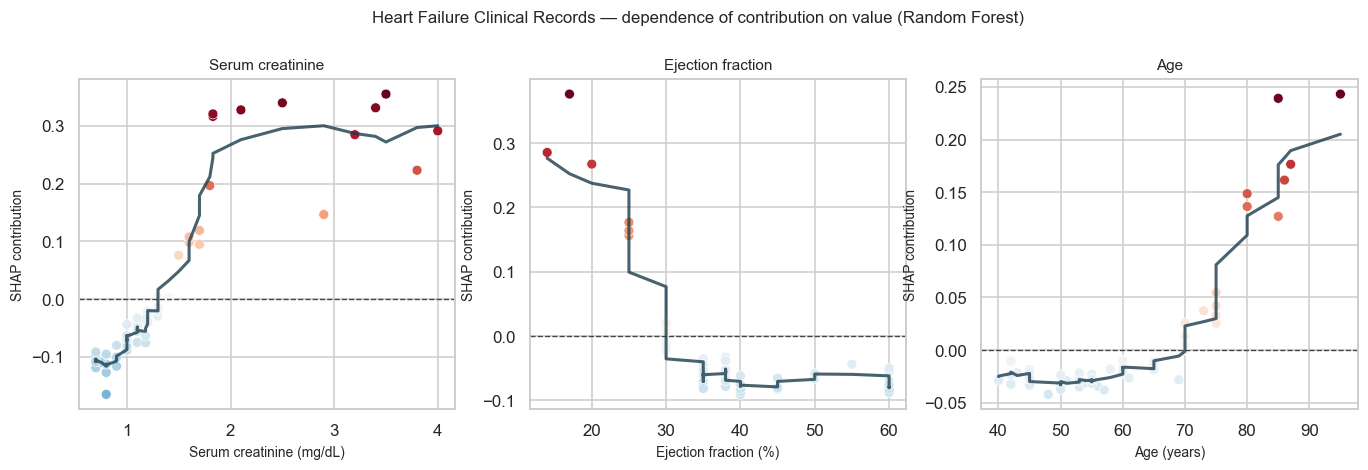

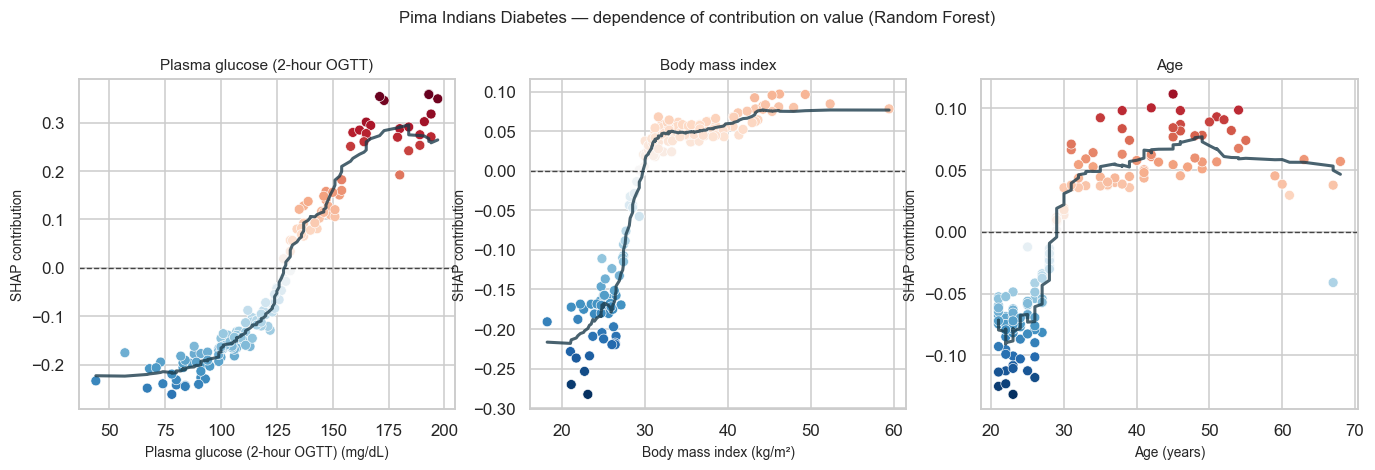

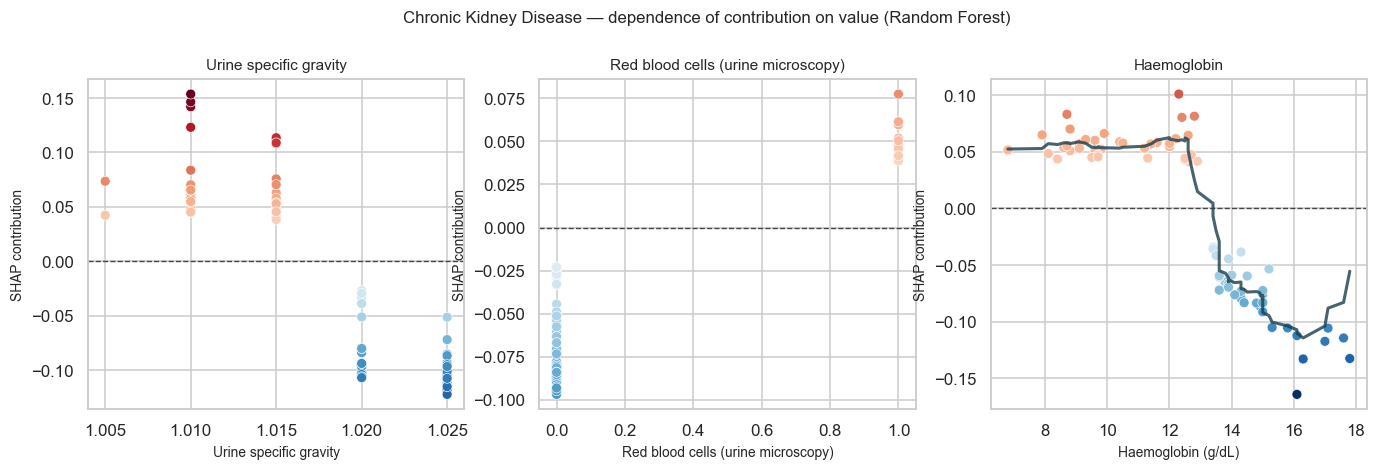

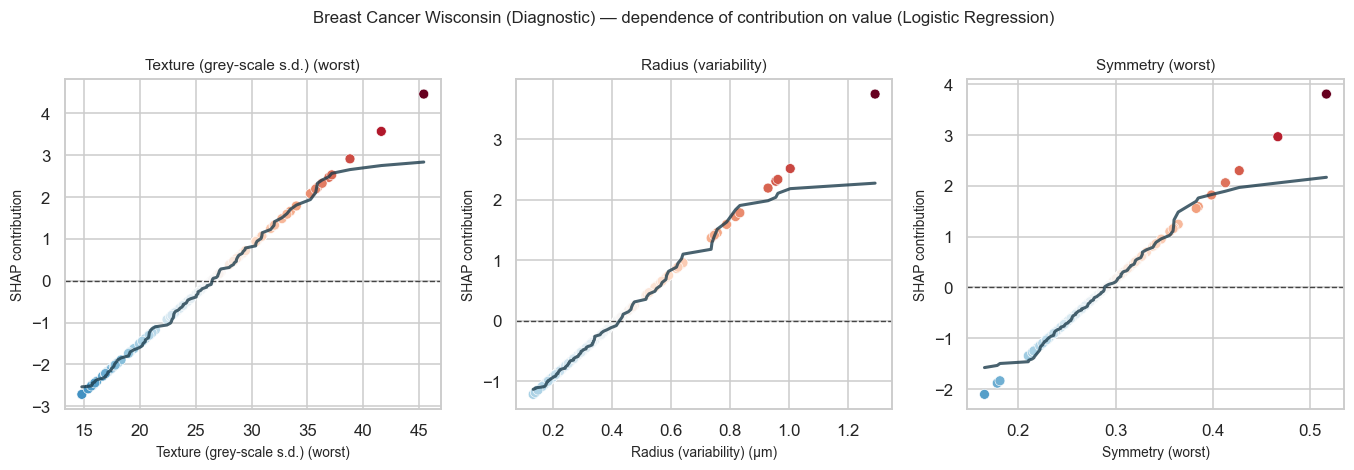

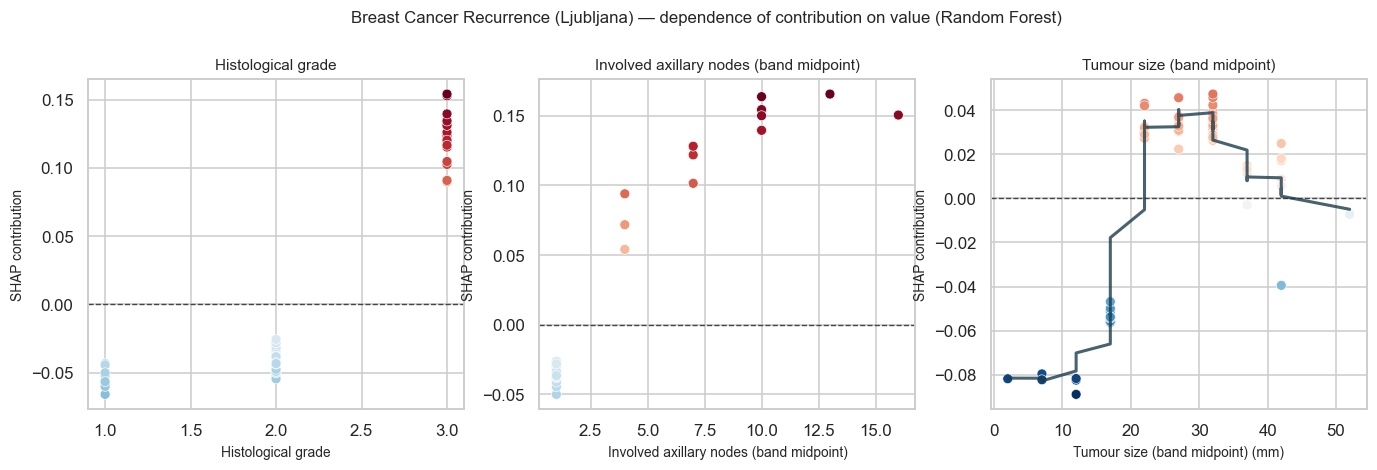

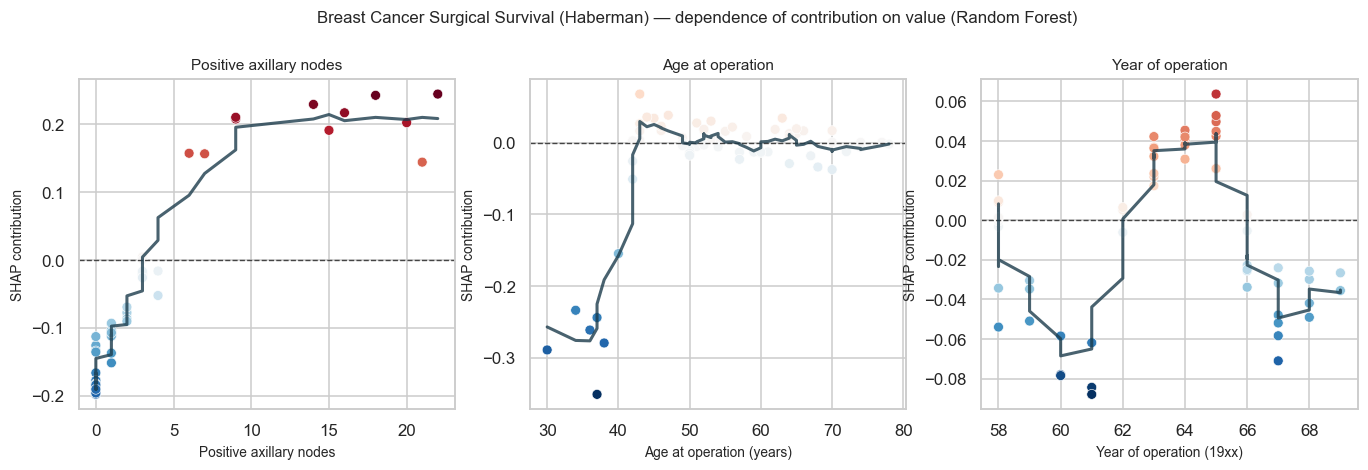

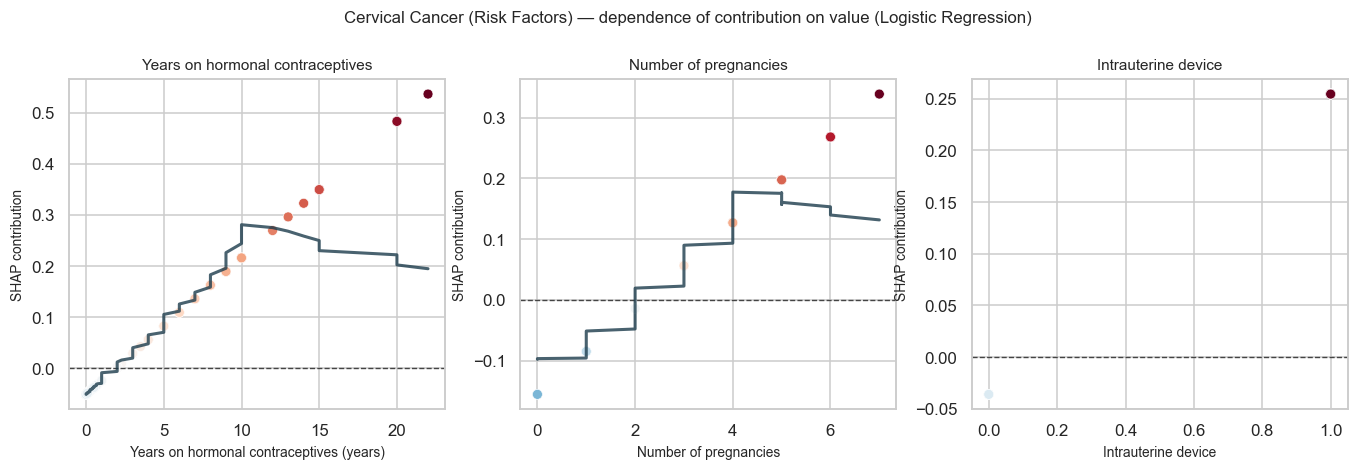

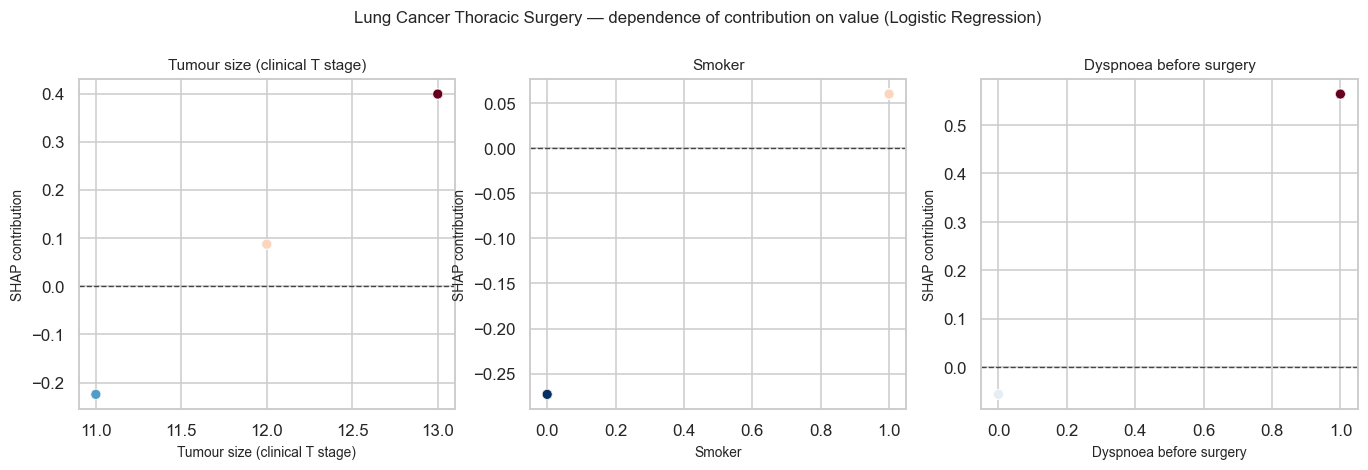

In [6]:
for slug, ds in schema.DATASETS.items():
    name = BEST[slug]
    sv = explainers[(slug, name)].values(bundles[slug]["X_test"])
    X_raw = bundles[slug]["X_test_raw"]
    top3 = [f["feature"] for f in global_importance[slug]["features"][:3]]

    fig, axes = plt.subplots(1, 3, figsize=(15, 3.9))
    for ax, feat in zip(axes, top3):
        idx = ds.feature_names.index(feat)
        f = ds.feature(feat)
        x = X_raw[feat].values
        pts = ax.scatter(x, sv[:, idx], c=sv[:, idx], cmap="RdBu_r",
                         edgecolor="white", linewidth=0.4, s=42,
                         vmin=-np.abs(sv[:, idx]).max(),
                         vmax=np.abs(sv[:, idx]).max())
        ax.axhline(0, color="#444", linewidth=0.9, linestyle="--")
        if len(np.unique(x[~np.isnan(x)])) > 6:
            order = np.argsort(x)
            window = max(5, len(x) // 8)
            smooth = pd.Series(sv[order, idx]).rolling(window, center=True,
                                                       min_periods=2).mean()
            ax.plot(x[order], smooth, color="#1b3b4b", linewidth=2, alpha=0.8)
        ax.set_xlabel(f"{f.label}" + (f" ({f.unit})" if f.unit else ""), fontsize=9)
        ax.set_ylabel("SHAP contribution", fontsize=9)
        ax.set_title(f.label, fontsize=10)

    plt.suptitle(f"{ds.title} — dependence of contribution on value "
                 f"({schema.MODEL_LABELS[name]})", y=1.04, fontsize=11)
    plt.savefig(FIGURES / f"04_shap_dependence_{slug}.png")
    plt.show()

## 4.4 LIME — five representative patients per dataset

Explaining only correct, confident predictions would be self-congratulatory.
For each dataset we select five real test patients spanning the outcomes that
actually matter clinically:

| Case | Why it is worth explaining |
|---|---|
| True positive | Does the model cite the right reasons when it is right? |
| True negative | Does it correctly identify *protective* evidence? |
| **False positive** | An unnecessary referral. Which feature misled it? |
| **False negative** | A missed diagnosis — the costliest error in screening. |
| Borderline (p ≈ 0.5) | Where a clinician must override, so the reasoning has to be legible. |

The false negative is the important one. In a deployed screening tool this is
the patient who goes home, and the explanation is the only artefact that lets a
clinician notice the model discounted something it should not have.


Heart Disease (Cleveland) — Logistic Regression


--- True positive (correctly flagged) ---
  actual: Heart disease present   |   predicted probability: 0.988
  The model estimates a high likelihood of “Heart disease present” (99%). Raising the estimate: Major vessels coloured by fluoroscopy (3), Thallium perfusion scan (Reversible defect), Exercise-induced angina (Yes).
    * Major vessels coloured by fluoroscopy of 3 pushed this prediction toward “Heart disease present”.  (SHAP +2.006)
    * Thallium perfusion scan of Reversible defect pushed this prediction toward “Heart disease present”.  (SHAP +0.650)
    * Exercise-induced angina of Yes pushed this prediction toward “Heart disease present”.  (SHAP +0.474)
    SHAP/LIME top-5 overlap: 80%

--- True negative (correctly cleared) ---
  actual: No heart disease   |   predicted probability: 0.042
  The model estimates a low likelihood of “Heart disease present” (4%). Lowering it: Chest pain type (Typical angina), Sex (Female), Thallium perfusion scan (Normal).
    * Chest pain type of

--- False positive (unnecessary referral) ---
  actual: No heart disease   |   predicted probability: 0.938
  The model estimates a high likelihood of “Heart disease present” (94%). Raising the estimate: Major vessels coloured by fluoroscopy (3), Thallium perfusion scan (Reversible defect), Sex (Male).
    * Major vessels coloured by fluoroscopy of 3 pushed this prediction toward “Heart disease present”.  (SHAP +2.006)
    * Thallium perfusion scan of Reversible defect pushed this prediction toward “Heart disease present”.  (SHAP +0.650)
    * Sex of Male pushed this prediction toward “Heart disease present”.  (SHAP +0.325)
    SHAP/LIME top-5 overlap: 80%

--- False negative (missed case) ---
  actual: Heart disease present   |   predicted probability: 0.360
  The model estimates a moderate likelihood of “Heart disease present” (36%). Raising the estimate: Exercise-induced angina (Yes). Lowering it: Sex (Female), Thallium perfusion scan (Normal).
    * Sex of Female pushed this predic

    SHAP/LIME top-5 overlap: 80%



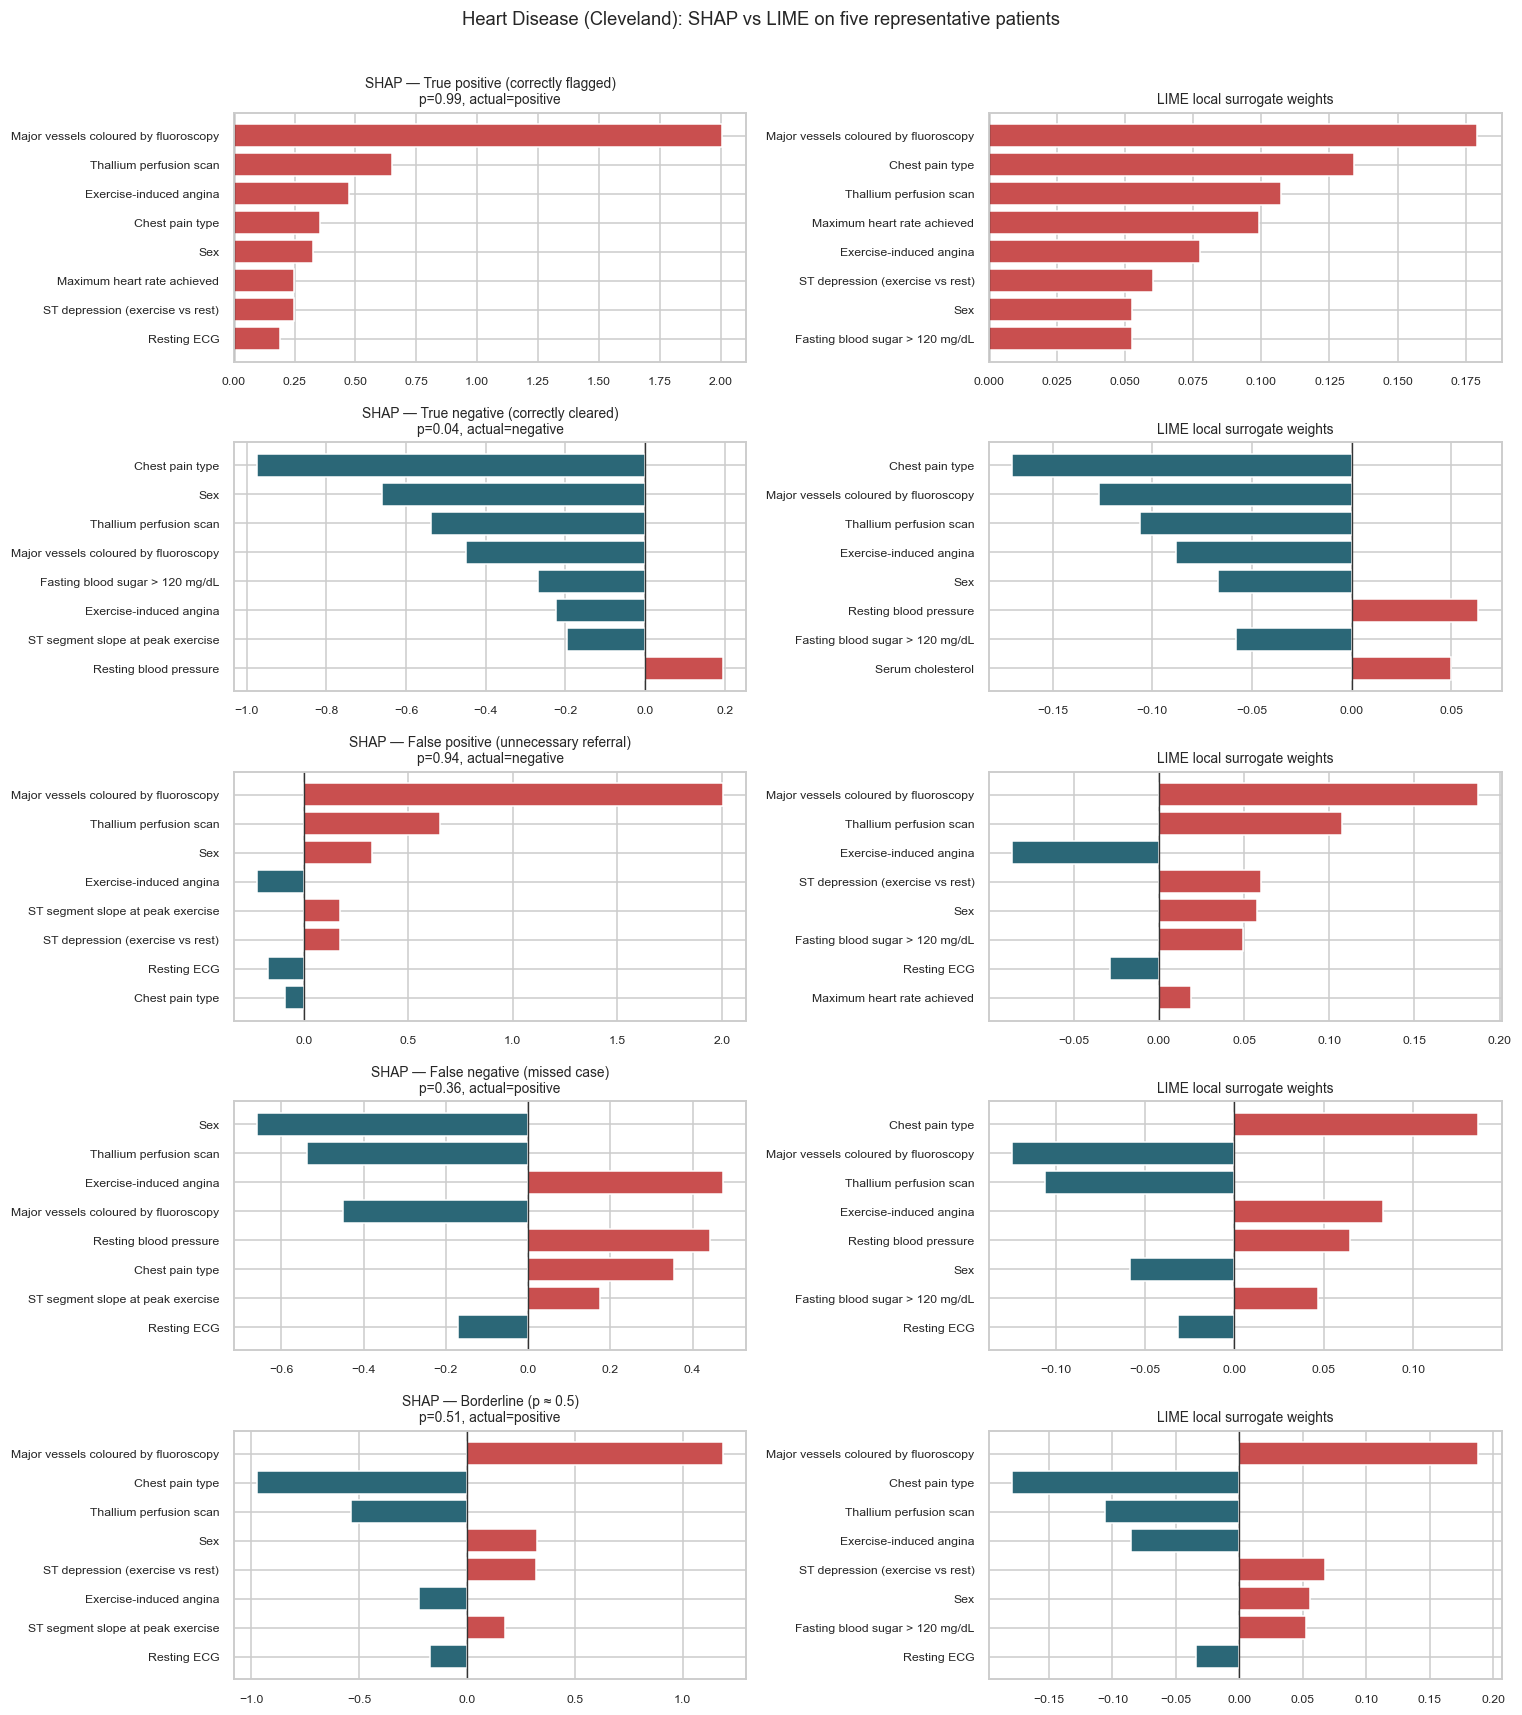


Heart Failure Clinical Records — Random Forest


--- True positive (correctly flagged) ---
  actual: Death during follow-up   |   predicted probability: 0.799
  The model estimates a high likelihood of “Death during follow-up” (80%). Raising the estimate: Ejection fraction (20 %), Serum creatinine (2.90 mg/dL), Serum sodium (127 mEq/L).
    * Ejection fraction of 20 % (low for this range) pushed this prediction toward “Death during follow-up”.  (SHAP +0.267)
    * Serum creatinine of 2.90 mg/dL (low for this range) pushed this prediction toward “Death during follow-up”.  (SHAP +0.146)
    * Serum sodium of 127 mEq/L (mid-range for this range) pushed this prediction toward “Death during follow-up”.  (SHAP +0.086)
    SHAP/LIME top-5 overlap: 80%



--- True negative (correctly cleared) ---
  actual: Survived follow-up   |   predicted probability: 0.030
  The model estimates a low likelihood of “Death during follow-up” (3%). Lowering it: Serum creatinine (0.70 mg/dL), Ejection fraction (40 %), Age (55 years).
    * Serum creatinine of 0.70 mg/dL (low for this range) pushed this prediction toward “Survived follow-up”.  (SHAP -0.091)
    * Ejection fraction of 40 % (mid-range for this range) pushed this prediction toward “Survived follow-up”.  (SHAP -0.083)
    * Age of 55 years (low for this range) pushed this prediction toward “Survived follow-up”.  (SHAP -0.028)
    SHAP/LIME top-5 overlap: 80%



--- False positive (unnecessary referral) ---
  actual: Survived follow-up   |   predicted probability: 0.842
  The model estimates a high likelihood of “Death during follow-up” (84%). Raising the estimate: Serum creatinine (2.10 mg/dL), Age (80 years), Serum sodium (134 mEq/L).
    * Serum creatinine of 2.10 mg/dL (low for this range) pushed this prediction toward “Death during follow-up”.  (SHAP +0.327)
    * Age of 80 years (high for this range) pushed this prediction toward “Death during follow-up”.  (SHAP +0.136)
    * Serum sodium of 134 mEq/L (mid-range for this range) pushed this prediction toward “Death during follow-up”.  (SHAP +0.064)
    SHAP/LIME top-5 overlap: 80%



--- False negative (missed case) ---
  actual: Death during follow-up   |   predicted probability: 0.120
  The model estimates a low likelihood of “Death during follow-up” (12%). Lowering it: Serum creatinine (1.00 mg/dL), Ejection fraction (35 %), Age (45 years).
    * Serum creatinine of 1.00 mg/dL (low for this range) pushed this prediction toward “Survived follow-up”.  (SHAP -0.077)
    * Ejection fraction of 35 % (mid-range for this range) pushed this prediction toward “Survived follow-up”.  (SHAP -0.060)
    * Age of 45 years (low for this range) pushed this prediction toward “Survived follow-up”.  (SHAP -0.026)
    SHAP/LIME top-5 overlap: 80%



--- Borderline (p ≈ 0.5) ---
  actual: Death during follow-up   |   predicted probability: 0.502
  The model estimates a moderate likelihood of “Death during follow-up” (50%). Raising the estimate: Age (85 years), Serum sodium (132 mEq/L). Lowering it: Ejection fraction (60 %).
    * Age of 85 years (high for this range) pushed this prediction toward “Death during follow-up”.  (SHAP +0.239)
    * Serum sodium of 132 mEq/L (mid-range for this range) pushed this prediction toward “Death during follow-up”.  (SHAP +0.076)
    * Ejection fraction of 60 % (high for this range) pushed this prediction toward “Survived follow-up”.  (SHAP -0.070)
    SHAP/LIME top-5 overlap: 80%



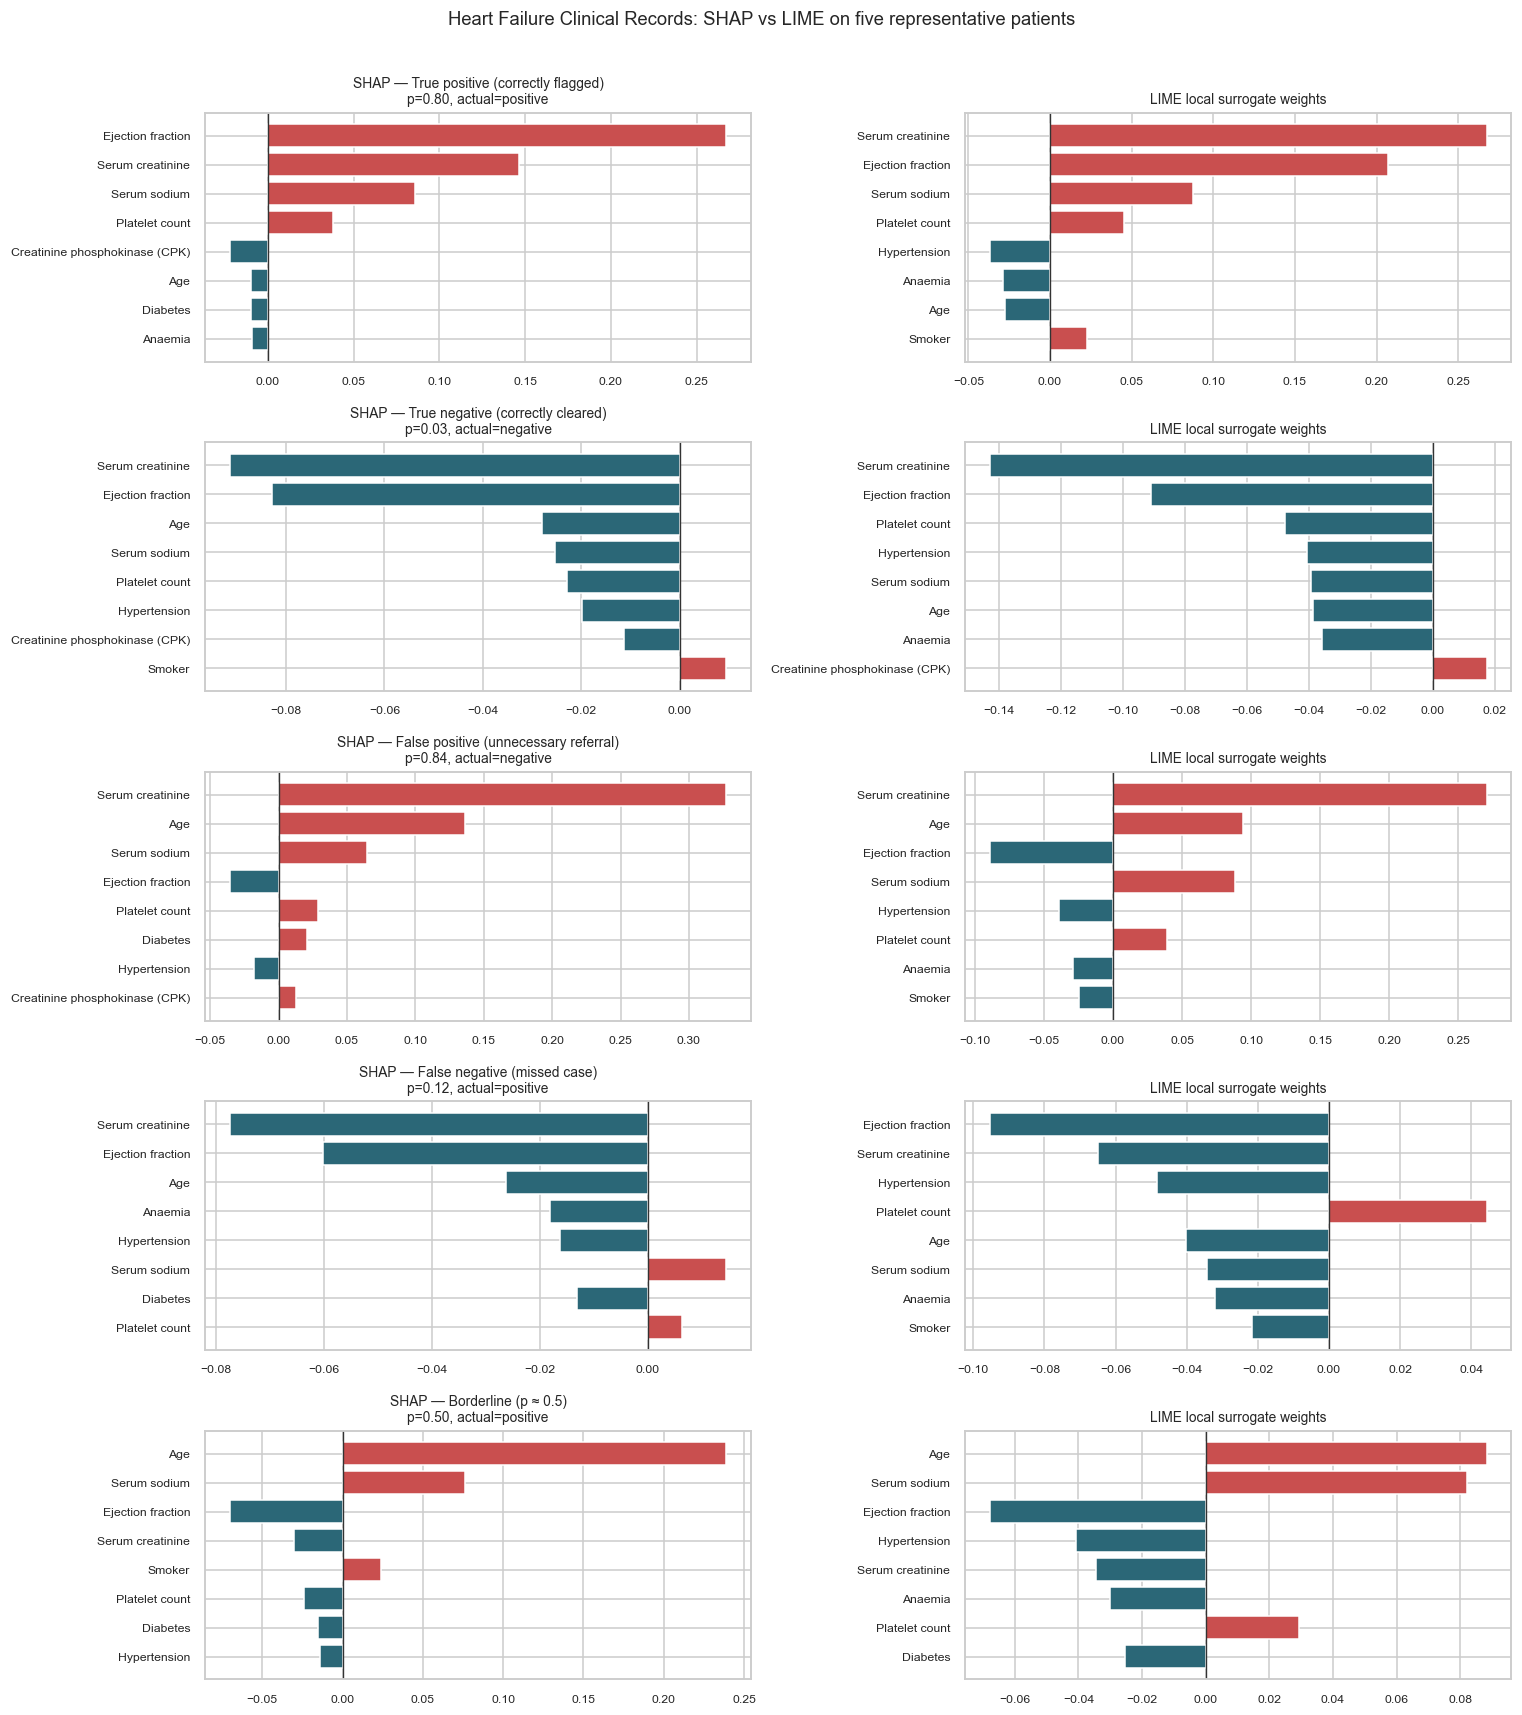


Pima Indians Diabetes — Random Forest


--- True positive (correctly flagged) ---
  actual: Diabetes onset   |   predicted probability: 0.914
  The model estimates a high likelihood of “Diabetes onset” (91%). Raising the estimate: Plasma glucose (2-hour OGTT) (194 mg/dL), Body mass index (35.9 kg/m²), Age (41 years).
    * Plasma glucose (2-hour OGTT) of 194 mg/dL (high for this range) pushed this prediction toward “Diabetes onset”.  (SHAP +0.270)
    * Body mass index of 35.9 kg/m² (mid-range for this range) pushed this prediction toward “Diabetes onset”.  (SHAP +0.046)
    * Age of 41 years (low for this range) pushed this prediction toward “Diabetes onset”.  (SHAP +0.043)
    SHAP/LIME top-5 overlap: 100%



--- True negative (correctly cleared) ---
  actual: No diabetes onset   |   predicted probability: 0.034
  The model estimates a low likelihood of “Diabetes onset” (3%). Lowering it: Plasma glucose (2-hour OGTT) (91 mg/dL), Body mass index (25.2 kg/m²), Age (23 years).
    * Plasma glucose (2-hour OGTT) of 91 mg/dL (low for this range) pushed this prediction toward “No diabetes onset”.  (SHAP -0.177)
    * Body mass index of 25.2 kg/m² (low for this range) pushed this prediction toward “No diabetes onset”.  (SHAP -0.137)
    * Age of 23 years (low for this range) pushed this prediction toward “No diabetes onset”.  (SHAP -0.063)
    SHAP/LIME top-5 overlap: 100%

--- False positive (unnecessary referral) ---
  actual: No diabetes onset   |   predicted probability: 0.853
  The model estimates a high likelihood of “Diabetes onset” (85%). Raising the estimate: Plasma glucose (2-hour OGTT) (179 mg/dL), Body mass index (34.2 kg/m²), Age (60 years).
    * Plasma glucose (2-hour OGTT) of 179 m

--- False negative (missed case) ---
  actual: Diabetes onset   |   predicted probability: 0.103
  The model estimates a low likelihood of “Diabetes onset” (10%). Lowering it: Plasma glucose (2-hour OGTT) (78 mg/dL), 2-hour serum insulin (88 mu U/mL), Age (26 years).
    * Plasma glucose (2-hour OGTT) of 78 mg/dL (low for this range) pushed this prediction toward “No diabetes onset”.  (SHAP -0.219)
    * 2-hour serum insulin of 88 mu U/mL (low for this range) pushed this prediction toward “No diabetes onset”.  (SHAP -0.078)
    * Age of 26 years (low for this range) pushed this prediction toward “No diabetes onset”.  (SHAP -0.069)
    SHAP/LIME top-5 overlap: 80%

--- Borderline (p ≈ 0.5) ---
  actual: Diabetes onset   |   predicted probability: 0.493
  The model estimates a moderate likelihood of “Diabetes onset” (49%). Raising the estimate: Diabetes pedigree function (1.321), Body mass index (32.0 kg/m²). Lowering it: 2-hour serum insulin (58 mu U/mL).
    * 2-hour serum insulin of 5

    SHAP/LIME top-5 overlap: 80%



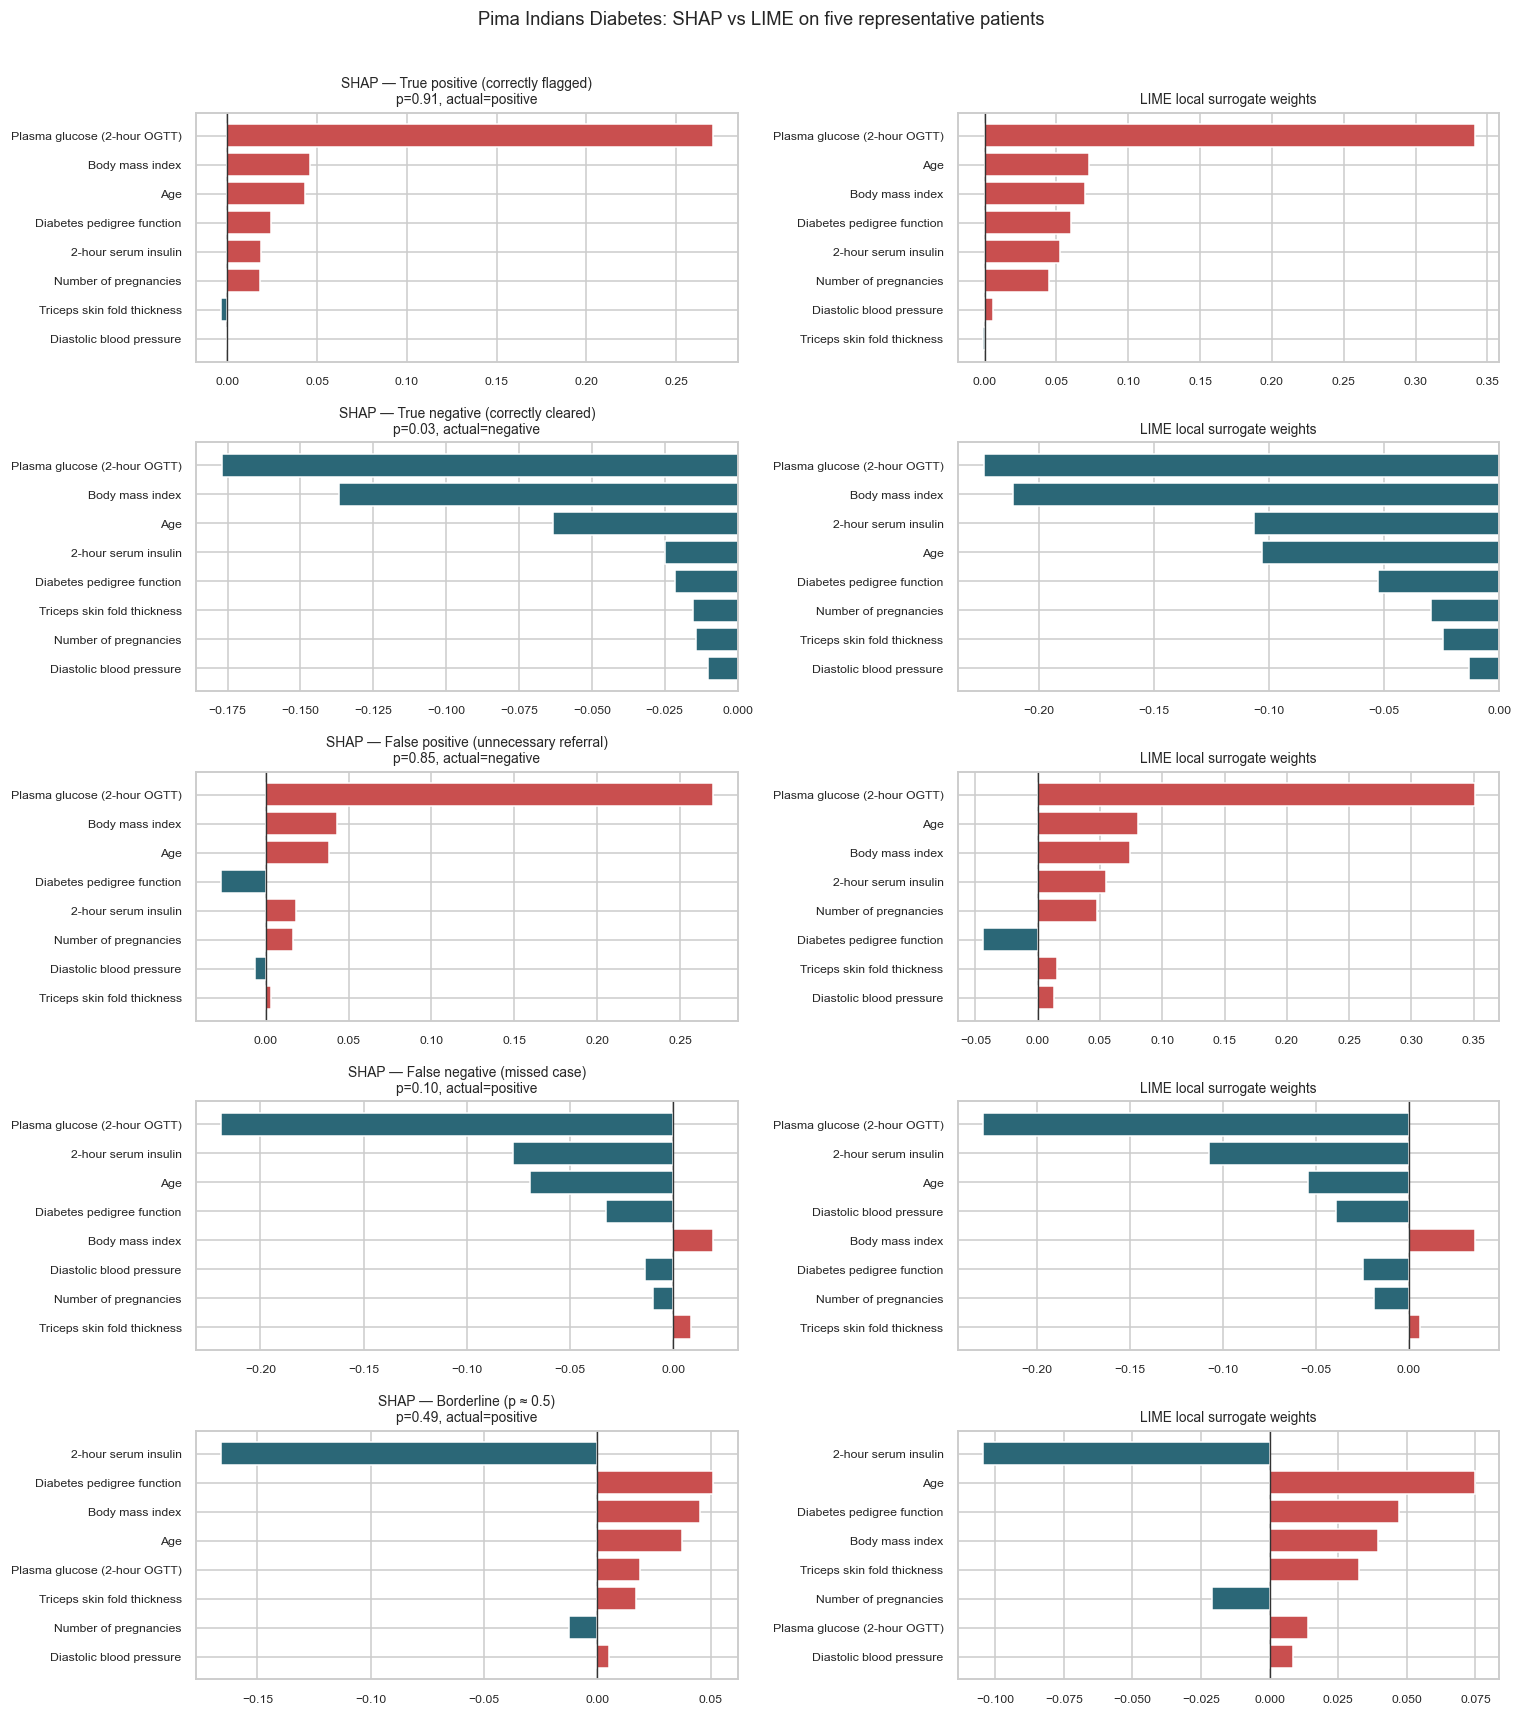


Chronic Kidney Disease — Random Forest
  note: no false_negative, false_positive exists in this test split (the model makes no such error here), so it cannot be shown.



--- True positive (correctly flagged) ---
  actual: Chronic kidney disease   |   predicted probability: 1.000
  The model estimates a high likelihood of “Chronic kidney disease” (100%). Raising the estimate: Red blood cells (urine microscopy) (Abnormal), Haemoglobin (10.4 g/dL), Urine specific gravity (1.010).
    * Red blood cells (urine microscopy) of Abnormal pushed this prediction toward “Chronic kidney disease”.  (SHAP +0.060)
    * Haemoglobin of 10.4 g/dL (mid-range for this range) pushed this prediction toward “Chronic kidney disease”.  (SHAP +0.059)
    * Urine specific gravity of 1.010 (low for this range) pushed this prediction toward “Chronic kidney disease”.  (SHAP +0.058)
    SHAP/LIME top-5 overlap: 60%



--- True negative (correctly cleared) ---
  actual: No chronic kidney disease   |   predicted probability: 0.000
  The model estimates a low likelihood of “Chronic kidney disease” (0%). Lowering it: Haemoglobin (17.0 g/dL), Packed cell volume (52 %), Urine specific gravity (1.025).
    * Haemoglobin of 17.0 g/dL (high for this range) pushed this prediction toward “No chronic kidney disease”.  (SHAP -0.117)
    * Packed cell volume of 52 % (high for this range) pushed this prediction toward “No chronic kidney disease”.  (SHAP -0.096)
    * Urine specific gravity of 1.025 (high for this range) pushed this prediction toward “No chronic kidney disease”.  (SHAP -0.087)
    SHAP/LIME top-5 overlap: 60%



--- Borderline (p ≈ 0.5) ---
  actual: Chronic kidney disease   |   predicted probability: 0.620
  The model estimates a moderate likelihood of “Chronic kidney disease” (62%). Raising the estimate: Red blood cells (urine microscopy) (Abnormal). Lowering it: Haemoglobin (16.1 g/dL), Packed cell volume (52 %).
    * Haemoglobin of 16.1 g/dL (high for this range) pushed this prediction toward “No chronic kidney disease”.  (SHAP -0.164)
    * Packed cell volume of 52 % (high for this range) pushed this prediction toward “No chronic kidney disease”.  (SHAP -0.134)
    * Red blood cells (urine microscopy) of Abnormal pushed this prediction toward “Chronic kidney disease”.  (SHAP +0.077)
    SHAP/LIME top-5 overlap: 40%



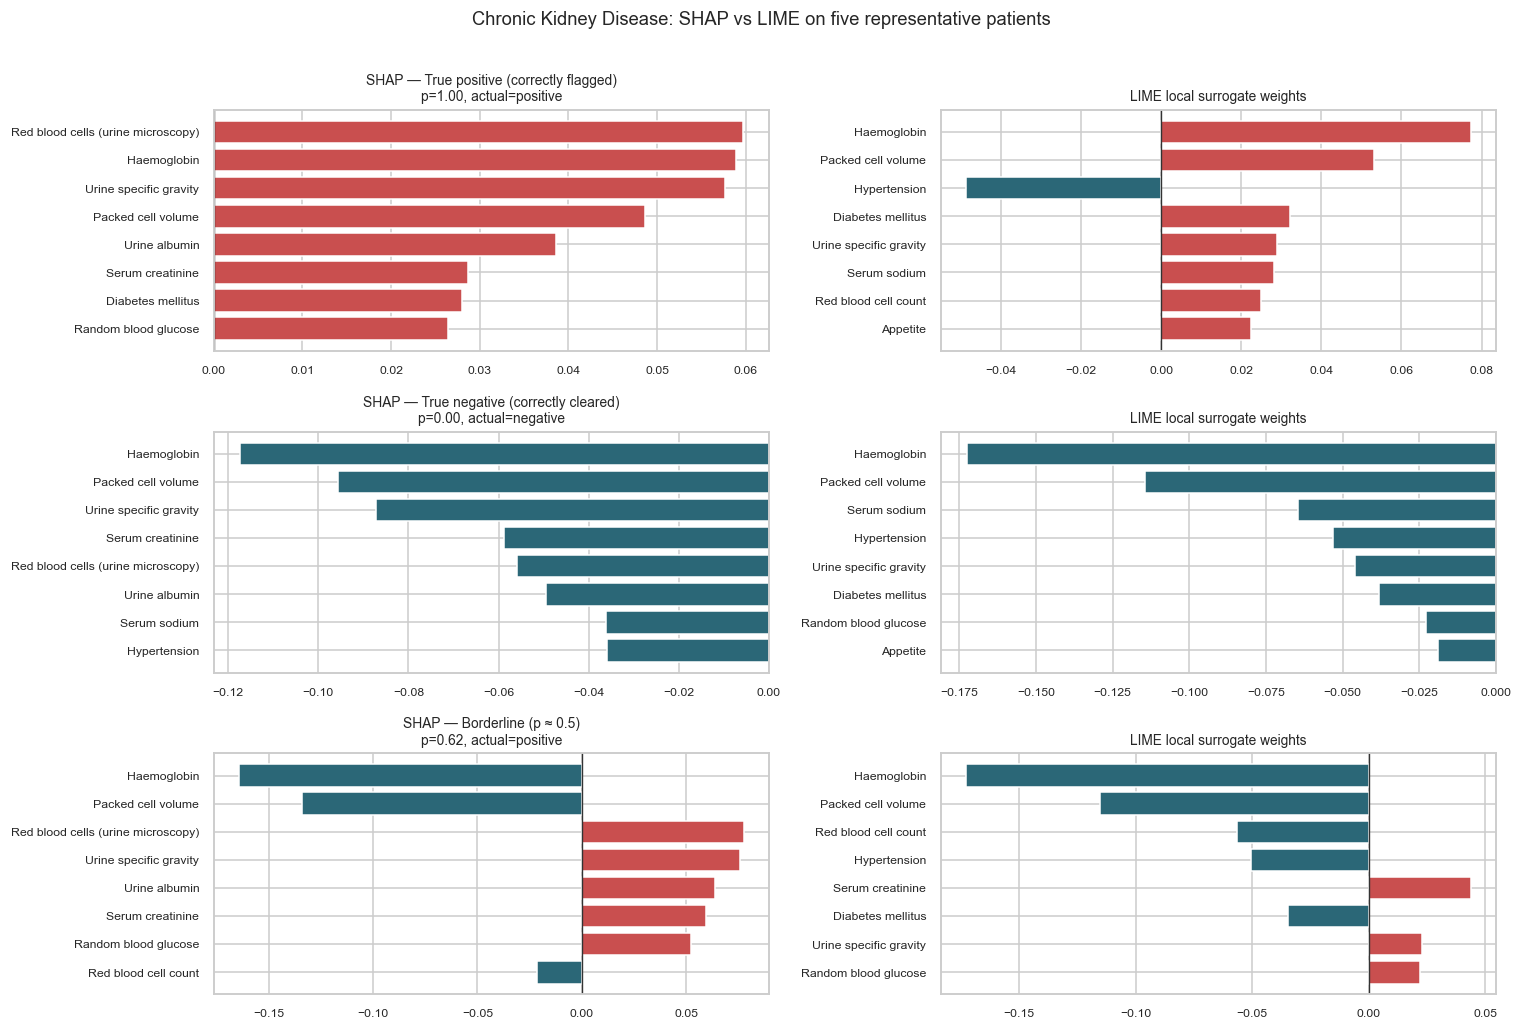


Breast Cancer Wisconsin (Diagnostic) — Logistic Regression
--- True positive (correctly flagged) ---
  actual: Malignant   |   predicted probability: 1.000
  The model estimates a high likelihood of “Malignant” (100%). Raising the estimate: Radius (variability) (1.29 µm), Area (worst) (2782 µm²), Area (variability) (180 µm²).
    * Radius (variability) of 1.29 µm (mid-range for this range) pushed this prediction toward “Malignant”.  (SHAP +3.743)
    * Area (worst) of 2782 µm² (mid-range for this range) pushed this prediction toward “Malignant”.  (SHAP +2.872)
    * Area (variability) of 180 µm² (low for this range) pushed this prediction toward “Malignant”.  (SHAP +2.649)
    SHAP/LIME top-5 overlap: 60%



--- True negative (correctly cleared) ---
  actual: Benign   |   predicted probability: 0.000
  The model estimates a low likelihood of “Malignant” (0%). Lowering it: Fractal dimension (variability) (0.0219), Compactness (variability) (0.094), Texture (grey-scale s.d.) (worst) (15.7).
    * Fractal dimension (variability) of 0.0219 (mid-range for this range) pushed this prediction toward “Benign”.  (SHAP -3.997)
    * Compactness (variability) of 0.094 (mid-range for this range) pushed this prediction toward “Benign”.  (SHAP -3.564)
    * Texture (grey-scale s.d.) (worst) of 15.7 (low for this range) pushed this prediction toward “Benign”.  (SHAP -2.515)
    SHAP/LIME top-5 overlap: 60%

--- False positive (unnecessary referral) ---
  actual: Benign   |   predicted probability: 0.511
  The model estimates a moderate likelihood of “Malignant” (51%). Raising the estimate: Texture (grey-scale s.d.) (worst) (41.6), Texture (grey-scale s.d.) (mean) (30.7). Lowering it: Symmetry (worst) (0.2

--- False negative (missed case) ---
  actual: Malignant   |   predicted probability: 0.063
  The model estimates a low likelihood of “Malignant” (6%). Lowering it: Texture (grey-scale s.d.) (worst) (20.9), Radius (variability) (0.28 µm), Symmetry (worst) (0.259).
    * Texture (grey-scale s.d.) (worst) of 20.9 (low for this range) pushed this prediction toward “Benign”.  (SHAP -1.298)
    * Radius (variability) of 0.28 µm (low for this range) pushed this prediction toward “Benign”.  (SHAP -0.601)
    * Symmetry (worst) of 0.259 (low for this range) pushed this prediction toward “Benign”.  (SHAP -0.528)
    SHAP/LIME top-5 overlap: 80%

--- Borderline (p ≈ 0.5) ---
  actual: Malignant   |   predicted probability: 0.504
  The model estimates a moderate likelihood of “Malignant” (50%). Raising the estimate: Symmetry (worst) (0.342). Lowering it: Texture (grey-scale s.d.) (worst) (20.2), Radius (variability) (0.27 µm).
    * Texture (grey-scale s.d.) (worst) of 20.2 (low for this range) p

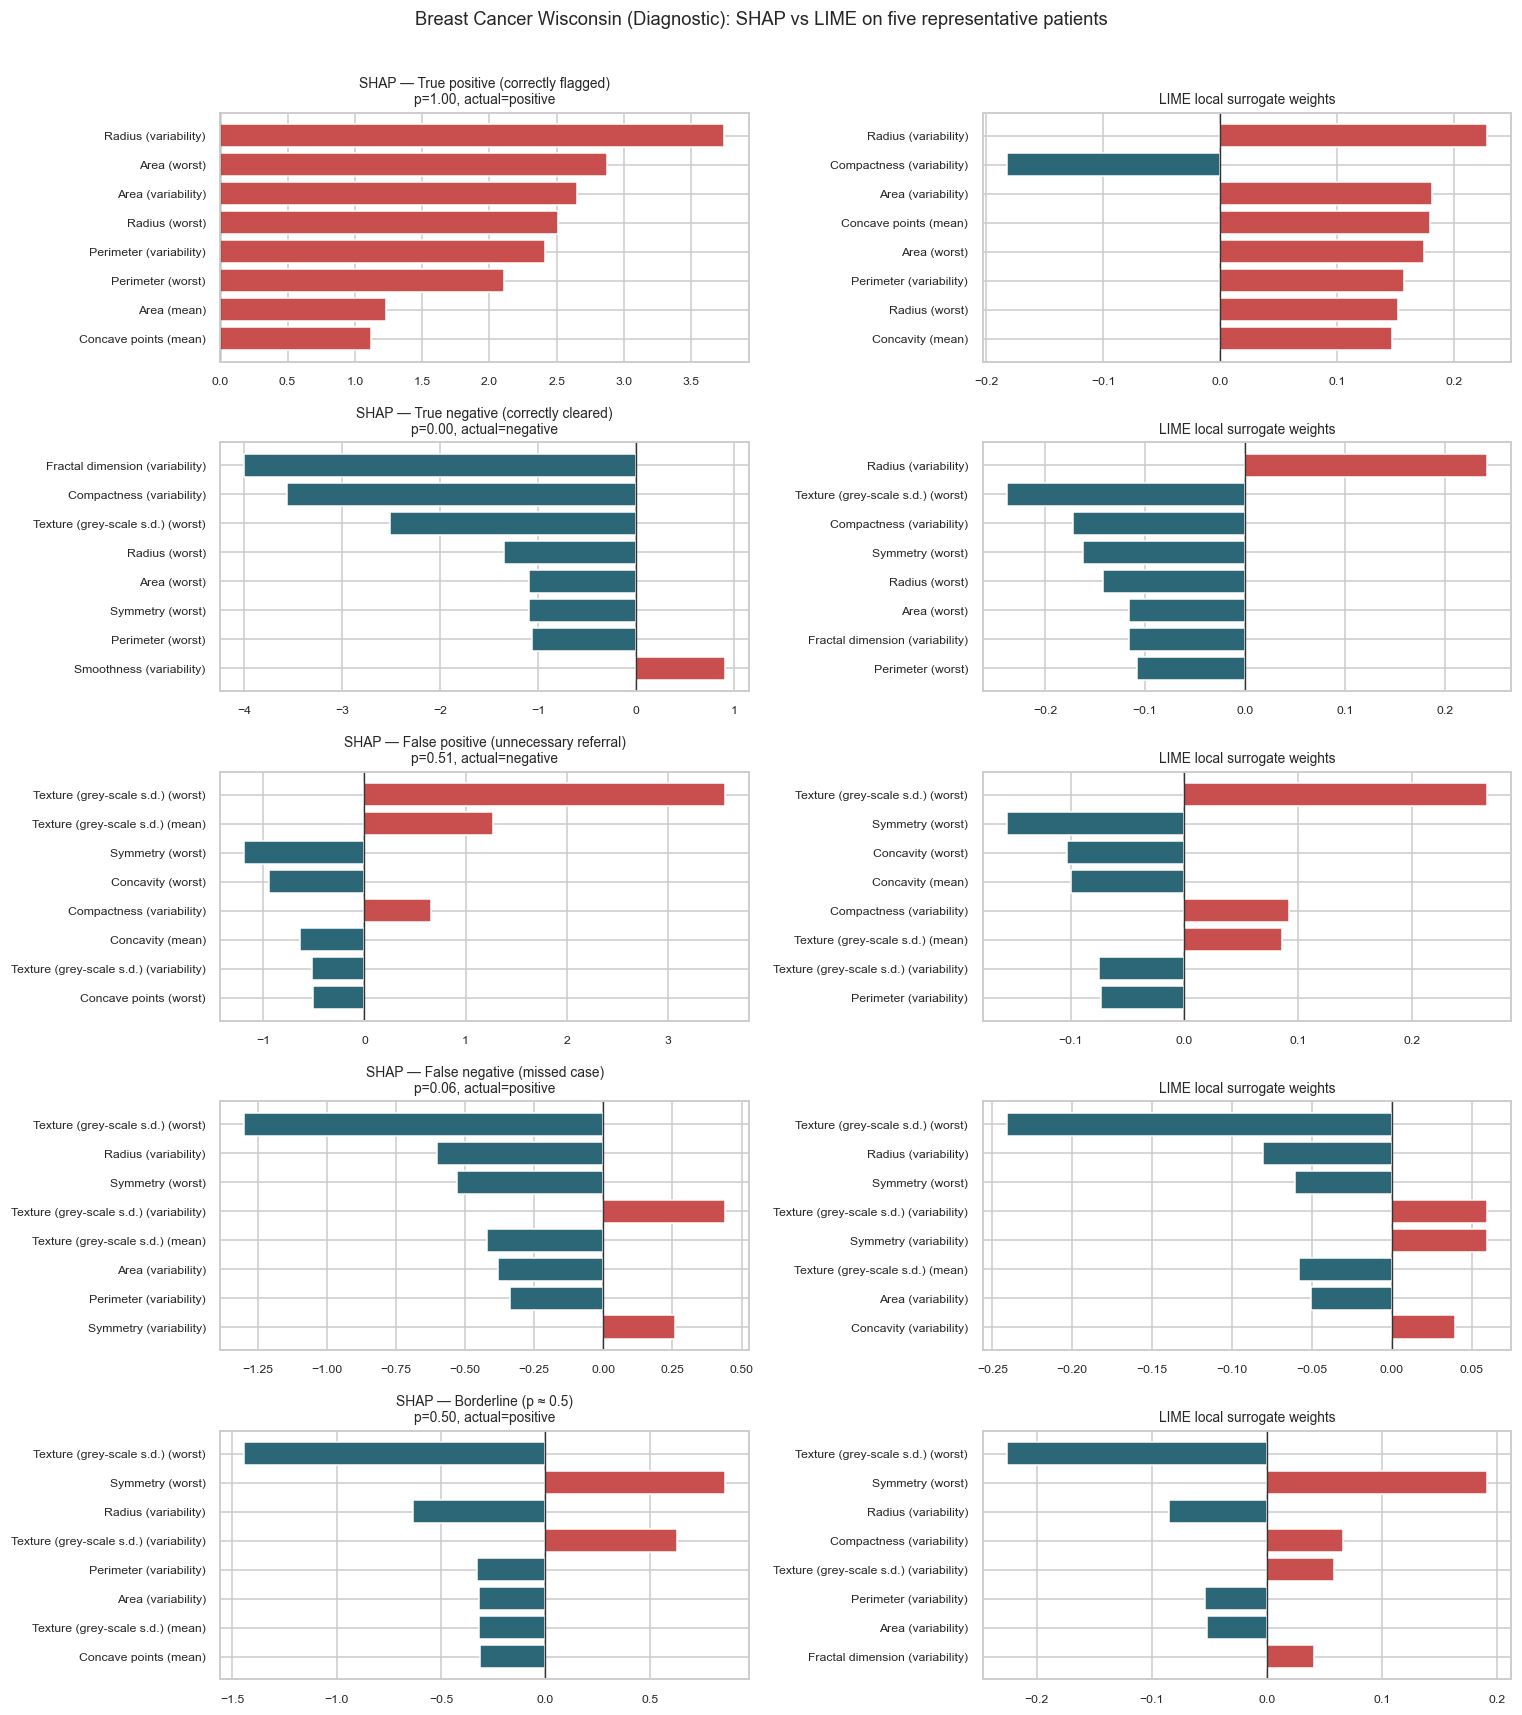


Breast Cancer Recurrence (Ljubljana) — Random Forest


--- True positive (correctly flagged) ---
  actual: Recurrence   |   predicted probability: 0.756
  The model estimates a high likelihood of “Recurrence” (76%). Raising the estimate: Involved axillary nodes (band midpoint) (13), Histological grade (Grade 3 (poorly differentiated)), Node capsular invasion (Yes).
    * Involved axillary nodes (band midpoint) of 13 (mid-range for this range) pushed this prediction toward “Recurrence”.  (SHAP +0.166)
    * Histological grade of Grade 3 (poorly differentiated) pushed this prediction toward “Recurrence”.  (SHAP +0.124)
    * Node capsular invasion of Yes pushed this prediction toward “Recurrence”.  (SHAP +0.098)
    SHAP/LIME top-5 overlap: 80%

--- True negative (correctly cleared) ---
  actual: No recurrence   |   predicted probability: 0.069
  The model estimates a low likelihood of “Recurrence” (7%). Lowering it: Tumour size (band midpoint) (2 mm), Histological grade (Grade 1 (well differentiated)), Involved axillary nodes (band midpoint

--- False positive (unnecessary referral) ---
  actual: No recurrence   |   predicted probability: 0.651
  The model estimates a moderate likelihood of “Recurrence” (65%). Raising the estimate: Histological grade (Grade 3 (poorly differentiated)), Involved axillary nodes (band midpoint) (4), Node capsular invasion (Yes).
    * Histological grade of Grade 3 (poorly differentiated) pushed this prediction toward “Recurrence”.  (SHAP +0.153)
    * Involved axillary nodes (band midpoint) of 4 (low for this range) pushed this prediction toward “Recurrence”.  (SHAP +0.094)
    * Node capsular invasion of Yes pushed this prediction toward “Recurrence”.  (SHAP +0.081)
    SHAP/LIME top-5 overlap: 80%



--- False negative (missed case) ---
  actual: Recurrence   |   predicted probability: 0.126
  The model estimates a low likelihood of “Recurrence” (13%). Lowering it: Tumour size (band midpoint) (17 mm), Histological grade (Grade 2 (moderately differentiated)), Involved axillary nodes (band midpoint) (1).
    * Tumour size (band midpoint) of 17 mm (low for this range) pushed this prediction toward “No recurrence”.  (SHAP -0.054)
    * Histological grade of Grade 2 (moderately differentiated) pushed this prediction toward “No recurrence”.  (SHAP -0.038)
    * Involved axillary nodes (band midpoint) of 1 (low for this range) pushed this prediction toward “No recurrence”.  (SHAP -0.037)
    SHAP/LIME top-5 overlap: 60%



--- Borderline (p ≈ 0.5) ---
  actual: Recurrence   |   predicted probability: 0.511
  The model estimates a moderate likelihood of “Recurrence” (51%). Raising the estimate: Histological grade (Grade 3 (poorly differentiated)), Involved axillary nodes (band midpoint) (4), Tumour size (band midpoint) (32 mm).
    * Histological grade of Grade 3 (poorly differentiated) pushed this prediction toward “Recurrence”.  (SHAP +0.131)
    * Involved axillary nodes (band midpoint) of 4 (low for this range) pushed this prediction toward “Recurrence”.  (SHAP +0.054)
    * Tumour size (band midpoint) of 32 mm (mid-range for this range) pushed this prediction toward “Recurrence”.  (SHAP +0.047)
    SHAP/LIME top-5 overlap: 60%



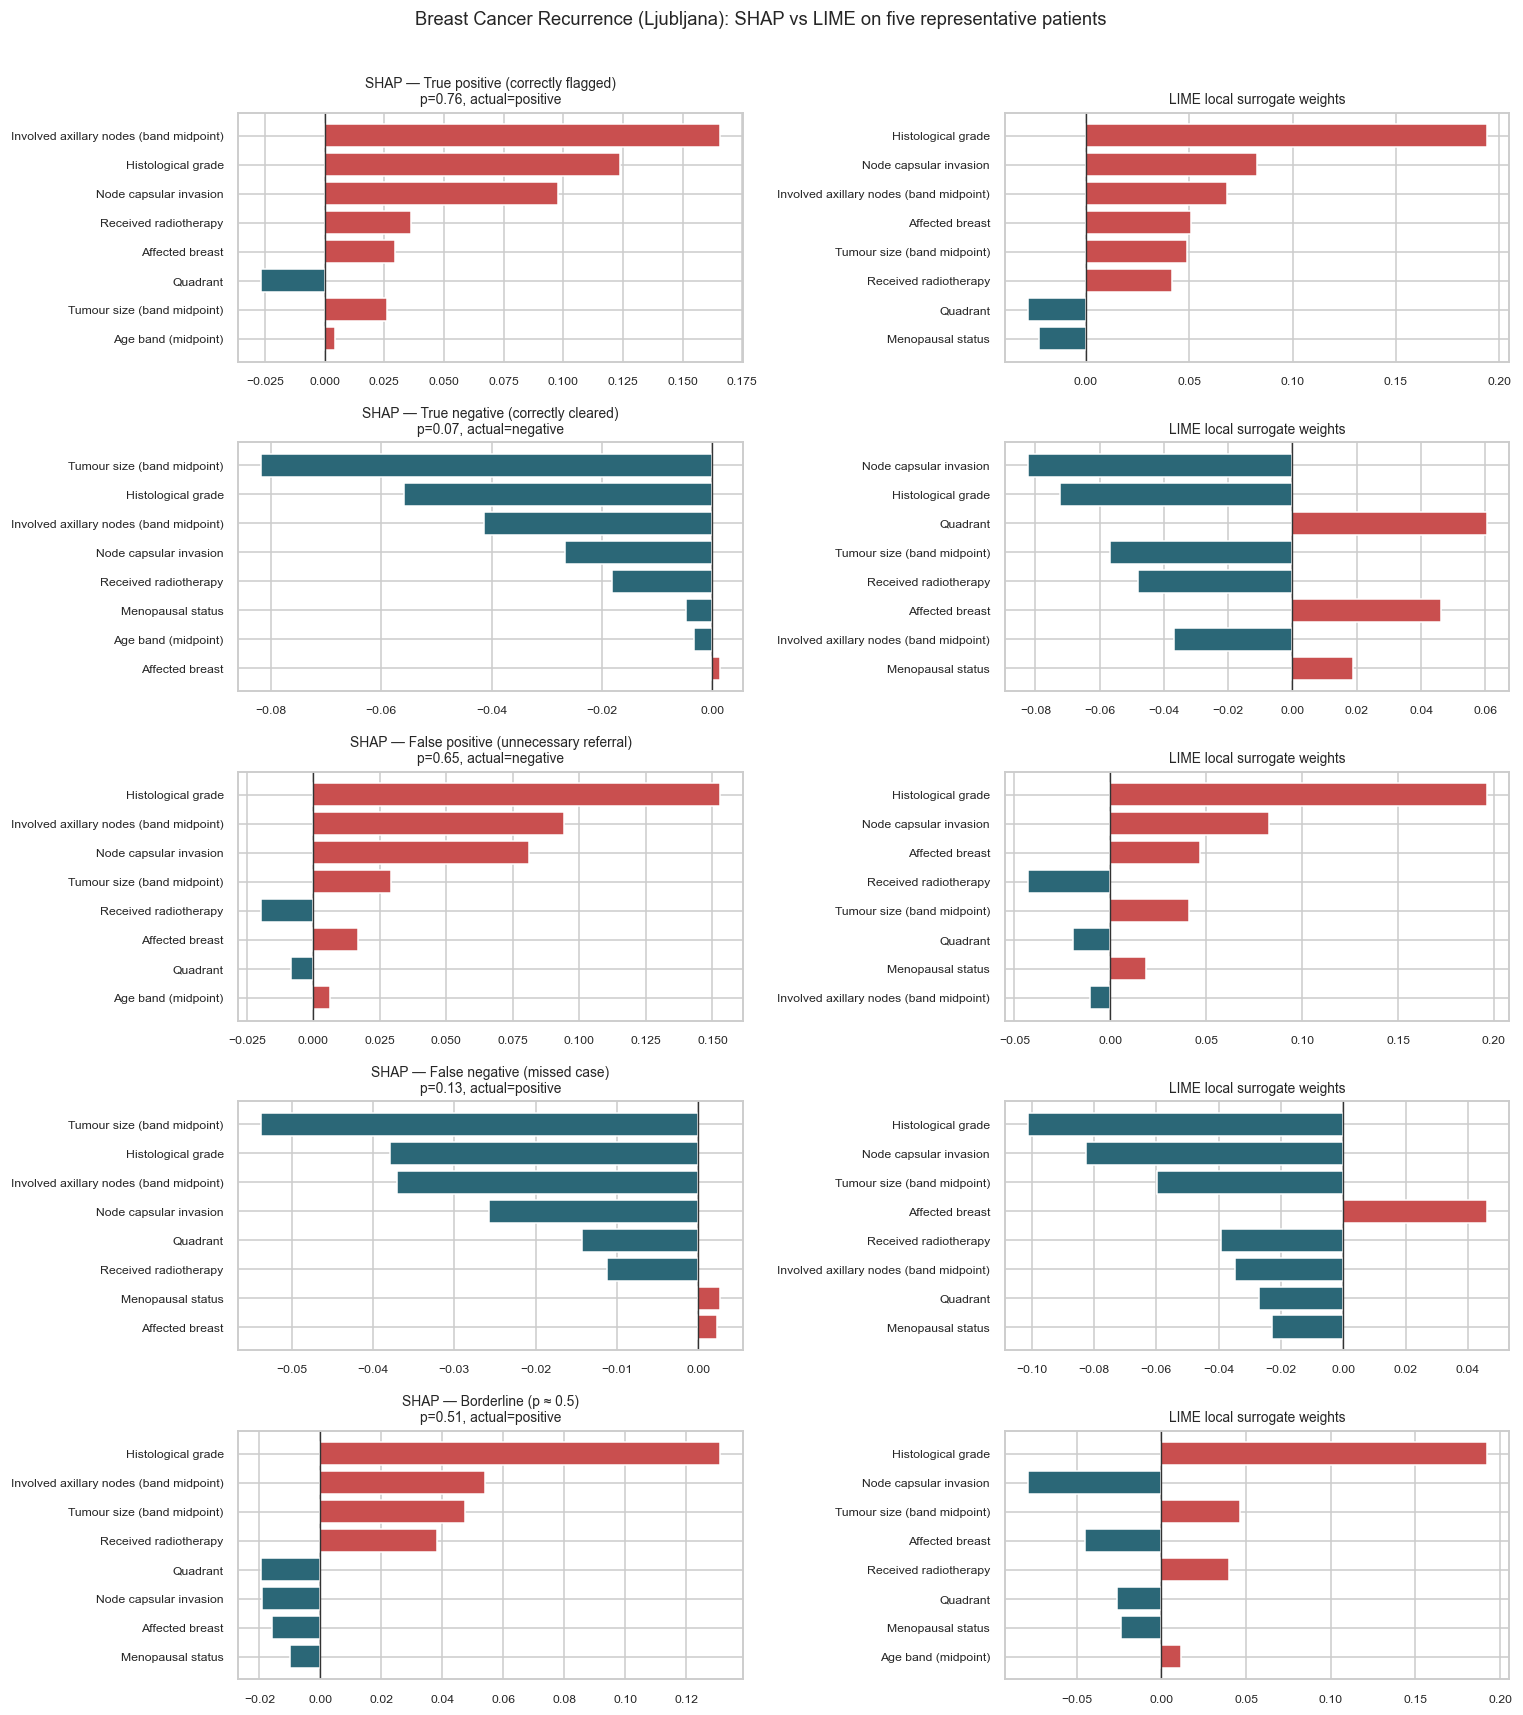


Breast Cancer Surgical Survival (Haberman) — Random Forest
--- True positive (correctly flagged) ---
  actual: Died within five years   |   predicted probability: 0.779
  The model estimates a high likelihood of “Died within five years” (78%). Raising the estimate: Positive axillary nodes (9), Year of operation (65 19xx), Age at operation (56 years).
    * Positive axillary nodes of 9 (low for this range) pushed this prediction toward “Died within five years”.  (SHAP +0.211)
    * Year of operation of 65 19xx (mid-range for this range) pushed this prediction toward “Died within five years”.  (SHAP +0.050)
    * Age at operation of 56 years (mid-range for this range) pushed this prediction toward “Died within five years”.  (SHAP +0.022)
    SHAP/LIME top-5 overlap: 60%



--- True negative (correctly cleared) ---
  actual: Survived five years   |   predicted probability: 0.064
  The model estimates a low likelihood of “Died within five years” (6%). Lowering it: Age at operation (36 years), Positive axillary nodes (1), Year of operation (60 19xx).
    * Age at operation of 36 years (low for this range) pushed this prediction toward “Survived five years”.  (SHAP -0.261)
    * Positive axillary nodes of 1 (low for this range) pushed this prediction toward “Survived five years”.  (SHAP -0.093)
    * Year of operation of 60 19xx (low for this range) pushed this prediction toward “Survived five years”.  (SHAP -0.078)
    SHAP/LIME top-5 overlap: 60%

--- False positive (unnecessary referral) ---
  actual: Survived five years   |   predicted probability: 0.799
  The model estimates a high likelihood of “Died within five years” (80%). Raising the estimate: Positive axillary nodes (22), Year of operation (65 19xx), Age at operation (64 years).
    * Positive axi

--- False negative (missed case) ---
  actual: Died within five years   |   predicted probability: 0.086
  The model estimates a low likelihood of “Died within five years” (9%). Lowering it: Age at operation (34 years), Positive axillary nodes (0), Year of operation (59 19xx).
    * Age at operation of 34 years (low for this range) pushed this prediction toward “Survived five years”.  (SHAP -0.234)
    * Positive axillary nodes of 0 (low for this range) pushed this prediction toward “Survived five years”.  (SHAP -0.126)
    * Year of operation of 59 19xx (low for this range) pushed this prediction toward “Survived five years”.  (SHAP -0.051)
    SHAP/LIME top-5 overlap: 60%

--- Borderline (p ≈ 0.5) ---
  actual: Survived five years   |   predicted probability: 0.503
  The model estimates a moderate likelihood of “Died within five years” (50%). Raising the estimate: Year of operation (65 19xx), Age at operation (77 years). Lowering it: Positive axillary nodes (3).
    * Year of operati

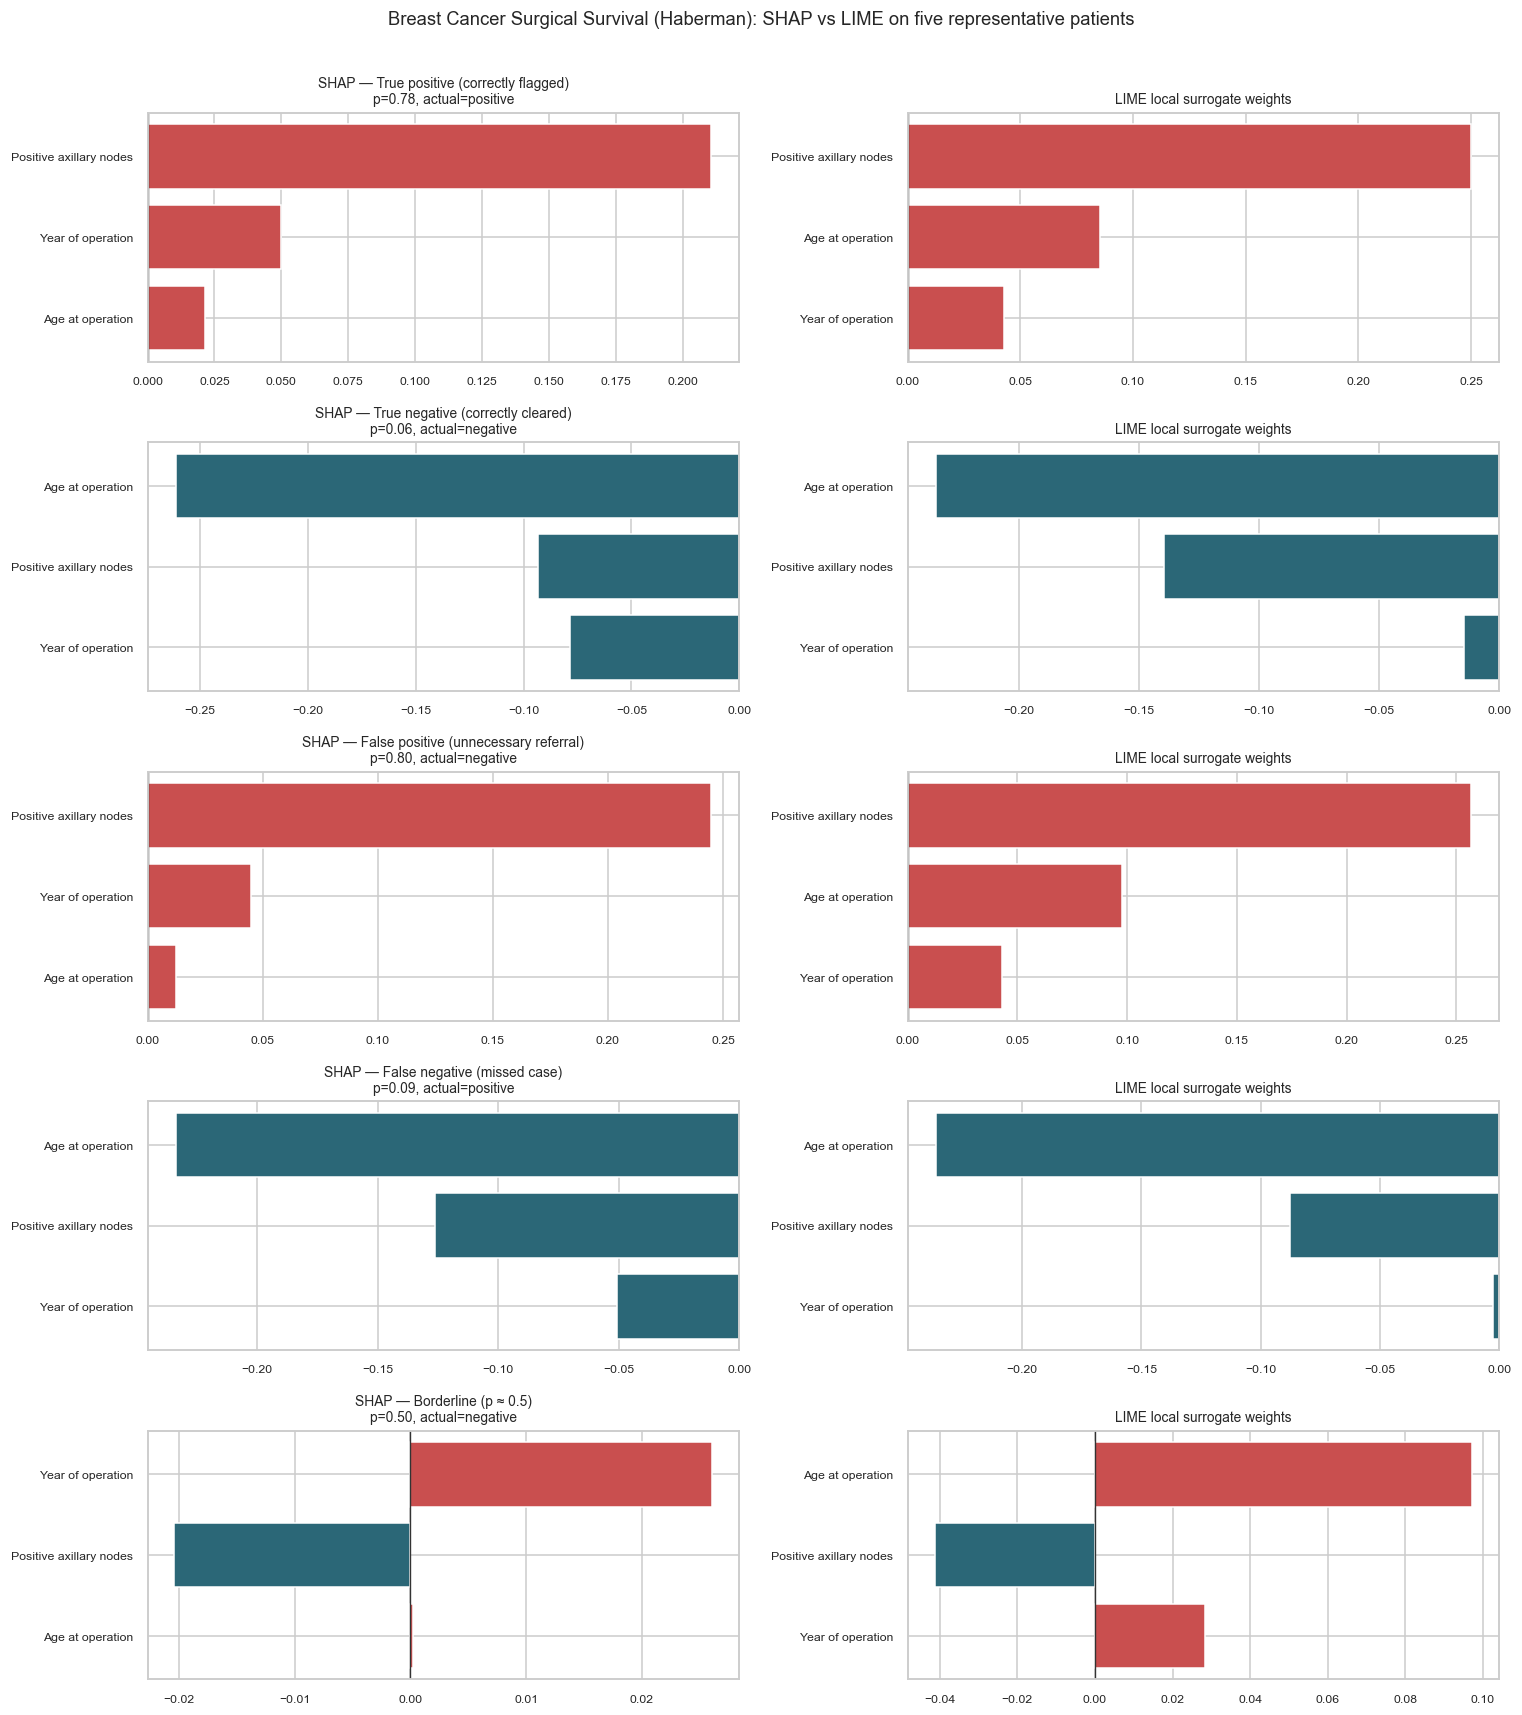


Cervical Cancer (Risk Factors) — Logistic Regression
--- True positive (correctly flagged) ---
  actual: Biopsy-confirmed cervical cancer   |   predicted probability: 0.652
  The model estimates a moderate likelihood of “Biopsy-confirmed cervical cancer” (65%). Raising the estimate: Vulvo-perineal condylomatosis (Yes), Condylomatosis (Yes), Any sexually transmitted infection (Yes).
    * Vulvo-perineal condylomatosis of Yes pushed this prediction toward “Biopsy-confirmed cervical cancer”.  (SHAP +0.414)
    * Condylomatosis of Yes pushed this prediction toward “Biopsy-confirmed cervical cancer”.  (SHAP +0.365)
    * Any sexually transmitted infection of Yes pushed this prediction toward “Biopsy-confirmed cervical cancer”.  (SHAP +0.202)
    SHAP/LIME top-5 overlap: 0%



--- True negative (correctly cleared) ---
  actual: Negative biopsy   |   predicted probability: 0.311
  The model estimates a low likelihood of “Biopsy-confirmed cervical cancer” (31%). Raising the estimate: Any sexually transmitted infection (Yes), Number of STI diagnoses (1). Lowering it: Syphilis (Yes).
    * Syphilis of Yes pushed this prediction toward “Negative biopsy”.  (SHAP -0.897)
    * Any sexually transmitted infection of Yes pushed this prediction toward “Biopsy-confirmed cervical cancer”.  (SHAP +0.202)
    * Number of STI diagnoses of 1 (mid-range for this range) pushed this prediction toward “Biopsy-confirmed cervical cancer”.  (SHAP +0.179)
    SHAP/LIME top-5 overlap: 0%

--- False positive (unnecessary referral) ---
  actual: Negative biopsy   |   predicted probability: 0.904
  The model estimates a high likelihood of “Biopsy-confirmed cervical cancer” (90%). Raising the estimate: Previous cervical intraepithelial neoplasia (Yes), Any previous diagnosis (Yes), Age (

--- Borderline (p ≈ 0.5) ---
  actual: Negative biopsy   |   predicted probability: 0.496
  The model estimates a moderate likelihood of “Biopsy-confirmed cervical cancer” (50%). Raising the estimate: Intrauterine device (Yes), Years with an IUD (8.0 years). Lowering it: Years on hormonal contraceptives (0.0 years).
    * Intrauterine device of Yes pushed this prediction toward “Biopsy-confirmed cervical cancer”.  (SHAP +0.254)
    * Years with an IUD of 8.0 years (mid-range for this range) pushed this prediction toward “Biopsy-confirmed cervical cancer”.  (SHAP +0.159)
    * Years on hormonal contraceptives of 0.0 years (low for this range) pushed this prediction toward “Negative biopsy”.  (SHAP -0.051)
    SHAP/LIME top-5 overlap: 0%



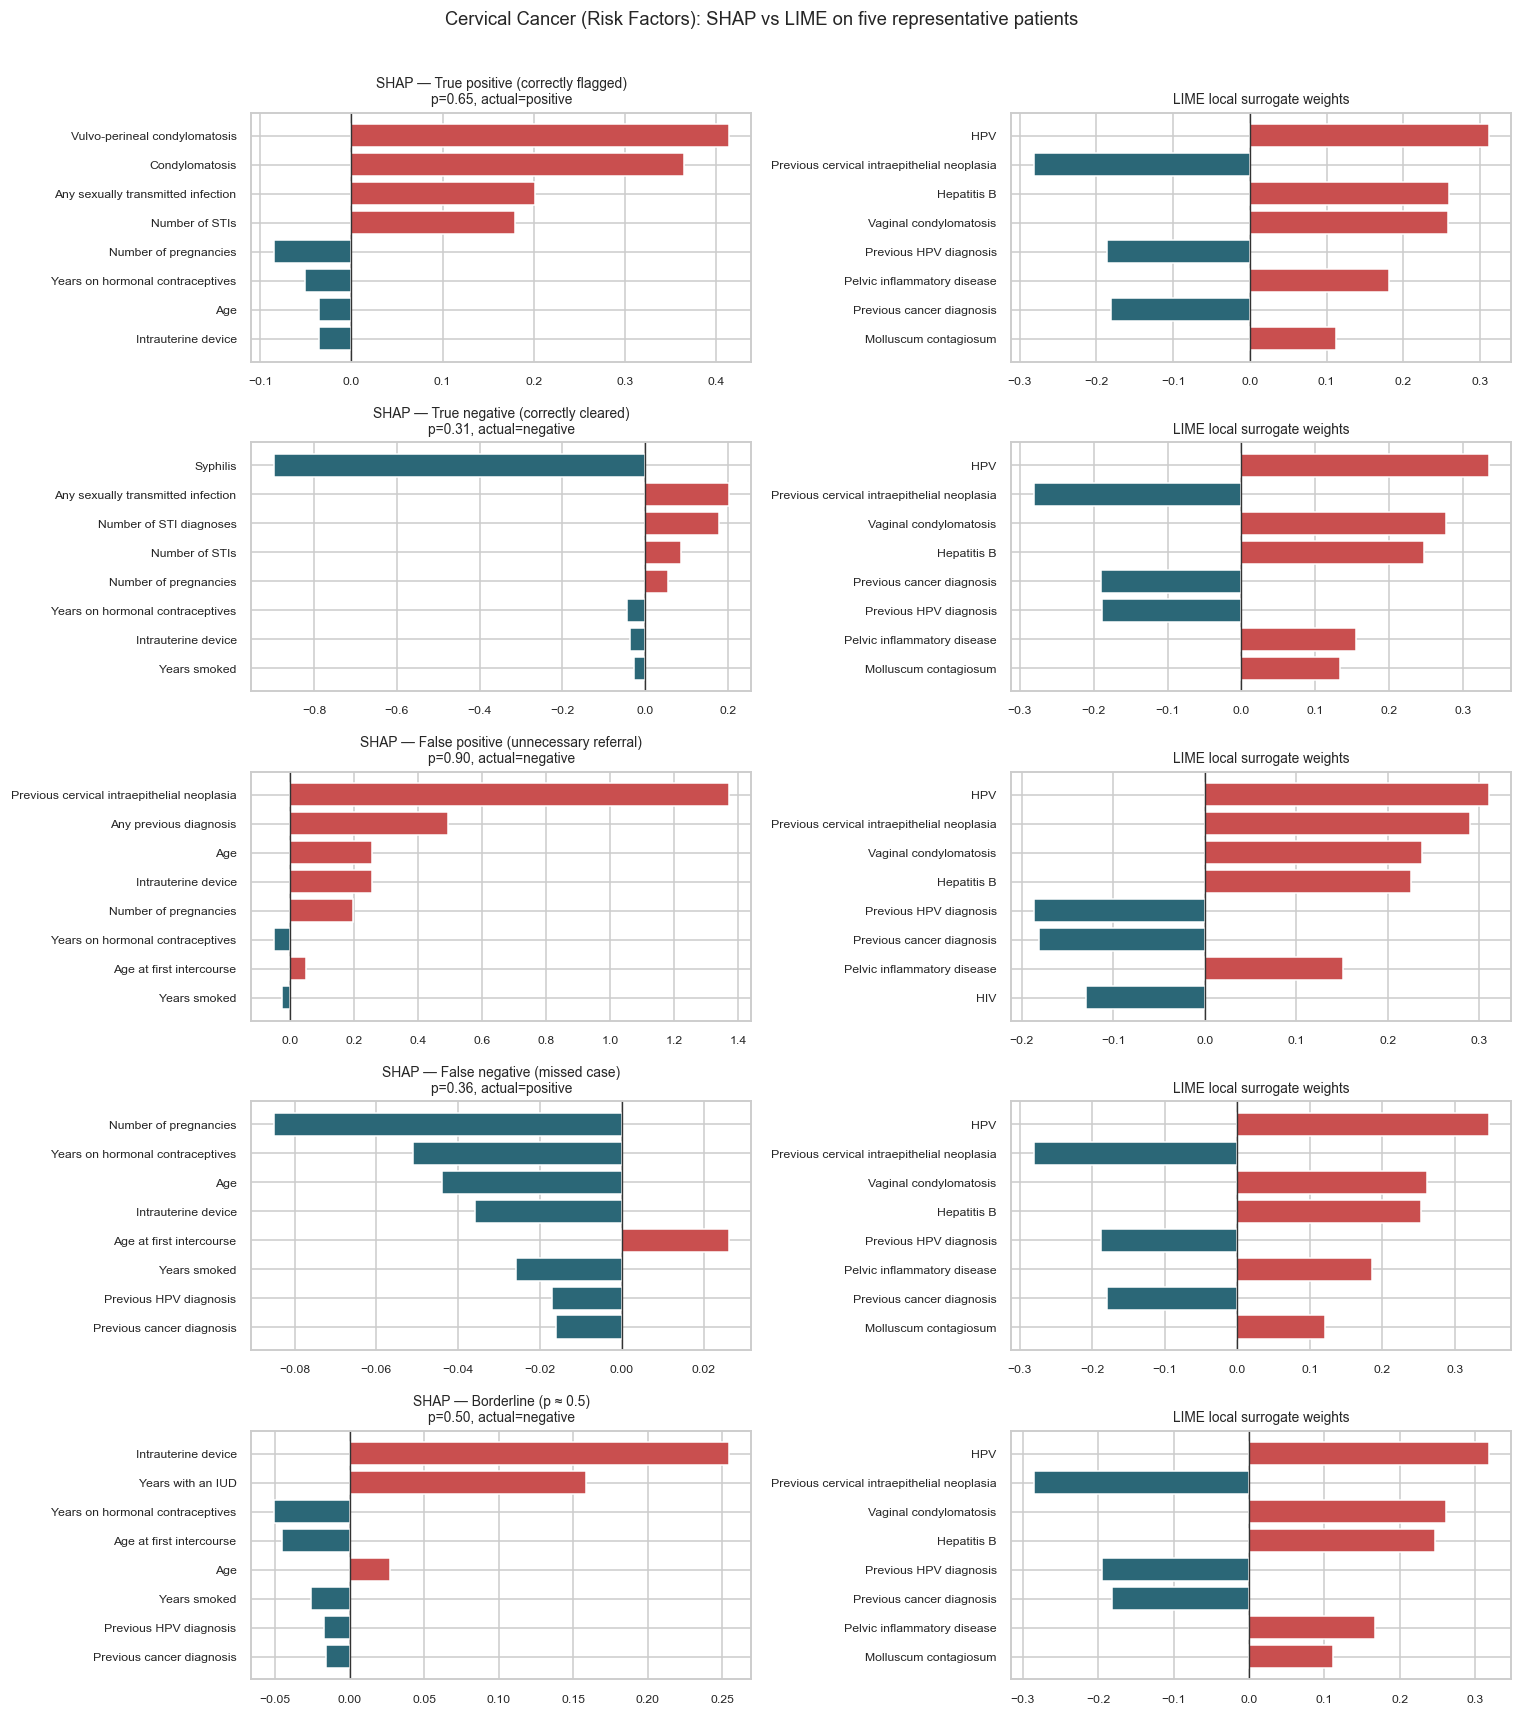


Lung Cancer Thoracic Surgery — Logistic Regression


--- True positive (correctly flagged) ---
  actual: Died within one year   |   predicted probability: 0.671
  The model estimates a high likelihood of “Died within one year” (67%). Raising the estimate: Type 2 diabetes (Yes), Weakness before surgery (Yes), Tumour size (clinical T stage) (T2).
    * Type 2 diabetes of Yes pushed this prediction toward “Died within one year”.  (SHAP +0.426)
    * Weakness before surgery of Yes pushed this prediction toward “Died within one year”.  (SHAP +0.169)
    * Tumour size (clinical T stage) of T2 pushed this prediction toward “Died within one year”.  (SHAP +0.087)
    SHAP/LIME top-5 overlap: 20%

--- True negative (correctly cleared) ---
  actual: Survived one year   |   predicted probability: 0.287
  The model estimates a low likelihood of “Died within one year” (29%). Lowering it: Smoker (No), Tumour size (clinical T stage) (T1 — smallest), Performance status (Zubrod) (0 — fully active).
    * Smoker of No pushed this prediction toward “Survive

--- False positive (unnecessary referral) ---
  actual: Survived one year   |   predicted probability: 0.731
  The model estimates a high likelihood of “Died within one year” (73%). Raising the estimate: Dyspnoea before surgery (Yes), Peripheral arterial disease (Yes), Tumour size (clinical T stage) (T2).
    * Dyspnoea before surgery of Yes pushed this prediction toward “Died within one year”.  (SHAP +0.564)
    * Peripheral arterial disease of Yes pushed this prediction toward “Died within one year”.  (SHAP +0.360)
    * Tumour size (clinical T stage) of T2 pushed this prediction toward “Died within one year”.  (SHAP +0.087)
    SHAP/LIME top-5 overlap: 40%

--- False negative (missed case) ---
  actual: Died within one year   |   predicted probability: 0.340
  The model estimates a moderate likelihood of “Died within one year” (34%). Raising the estimate: Diagnosis (ICD-10 group) (DGN8). Lowering it: Smoker (No), Tumour size (clinical T stage) (T1 — smallest).
    * Diagnosis (ICD-1

--- Borderline (p ≈ 0.5) ---
  actual: Survived one year   |   predicted probability: 0.500
  The model estimates a moderate likelihood of “Died within one year” (50%). Raising the estimate: Tumour size (clinical T stage) (T2), Smoker (Yes). Lowering it: Dyspnoea before surgery (No).
    * Tumour size (clinical T stage) of T2 pushed this prediction toward “Died within one year”.  (SHAP +0.087)
    * Smoker of Yes pushed this prediction toward “Died within one year”.  (SHAP +0.060)
    * Dyspnoea before surgery of No pushed this prediction toward “Survived one year”.  (SHAP -0.056)
    SHAP/LIME top-5 overlap: 40%



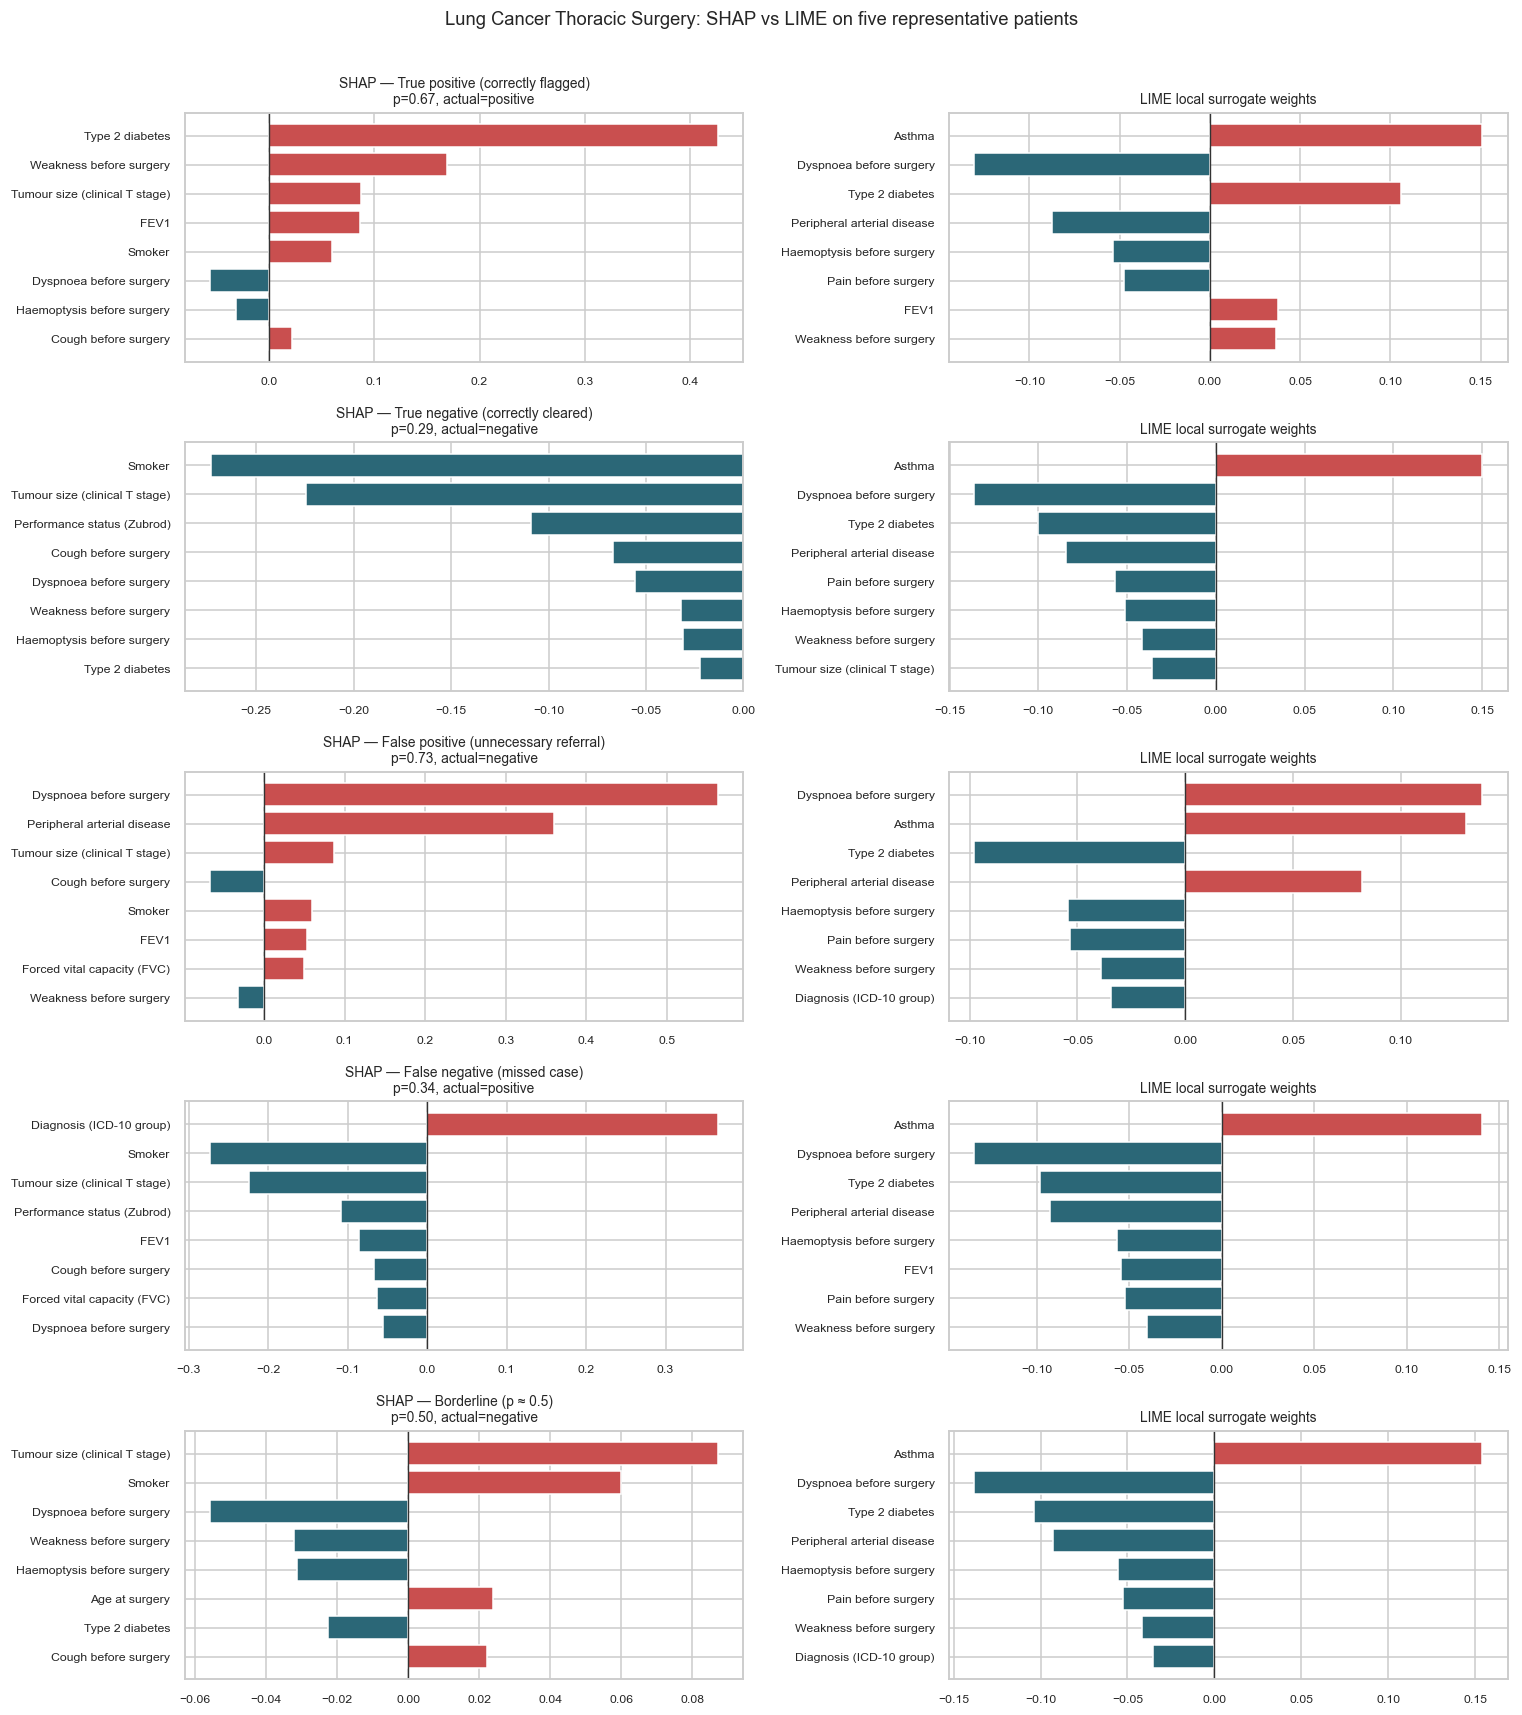

In [7]:
def pick_cases(y_true: pd.Series, proba: np.ndarray) -> dict[str, int]:
    """Positional indices of the five representative patients."""
    pred = (proba >= 0.5).astype(int)
    y = y_true.values
    picks: dict[str, int] = {}

    def best(mask, key):
        idx = np.where(mask)[0]
        return int(idx[np.argmax(key[idx])]) if len(idx) else None

    candidates = {
        "true_positive": best((y == 1) & (pred == 1), proba),
        "true_negative": best((y == 0) & (pred == 0), -proba),
        "false_positive": best((y == 0) & (pred == 1), proba),
        "false_negative": best((y == 1) & (pred == 0), -proba),
        "borderline": int(np.argmin(np.abs(proba - 0.5))),
    }
    return {k: v for k, v in candidates.items() if v is not None}


CASE_LABELS = {
    "true_positive": "True positive (correctly flagged)",
    "true_negative": "True negative (correctly cleared)",
    "false_positive": "False positive (unnecessary referral)",
    "false_negative": "False negative (missed case)",
    "borderline": "Borderline (p ≈ 0.5)",
}

case_studies = {}

for slug, ds in schema.DATASETS.items():
    name = BEST[slug]
    model, ex = models[(slug, name)], explainers[(slug, name)]
    X_test, X_raw = bundles[slug]["X_test"], bundles[slug]["X_test_raw"]
    y_test = bundles[slug]["y_test"]

    proba = model.predict_proba(X_test.values)[:, 1]
    lime_ex = explain.build_lime(bundles[slug]["X_train"], ds)
    cases = pick_cases(y_test, proba)
    sv_all = ex.values(X_test)

    print(f"\n{'=' * 78}\n{ds.title} — {schema.MODEL_LABELS[name]}\n{'=' * 78}")
    missing = set(CASE_LABELS) - set(cases)
    if missing:
        print(f"  note: no {', '.join(sorted(missing))} exists in this test split "
              f"(the model makes no such error here), so it cannot be shown.\n")

    entries = []
    n_cases = len(cases)
    fig, axes = plt.subplots(n_cases, 2, figsize=(14, 3.1 * n_cases))
    axes = np.atleast_2d(axes)

    for row, (kind, pos) in enumerate(cases.items()):
        patient_raw = X_raw.iloc[pos].to_dict()
        shap_row = sv_all[pos]
        weights = explain.lime_weights(
            lime_ex, X_test.iloc[pos].values,
            lambda A: model.predict_proba(np.asarray(A, dtype=float)), n=8,
        )
        factors = explain.top_factors(ds, shap_row, patient_raw, k=3)
        summary = explain.summarise(ds, float(proba[pos]), factors)

        print(f"--- {CASE_LABELS[kind]} ---")
        print(f"  actual: {ds.positive_label if y_test.iloc[pos] == 1 else ds.negative_label}"
              f"   |   predicted probability: {proba[pos]:.3f}")
        print(f"  {summary}")
        for f in factors:
            print(f"    * {f['sentence']}  (SHAP {f['shap_value']:+.3f})")

        # left: SHAP contributions | right: LIME surrogate weights
        shap_order = np.argsort(np.abs(shap_row))[::-1][:8][::-1]
        ax = axes[row, 0]
        ax.barh(
            [ds.feature(ds.feature_names[i]).label for i in shap_order],
            [shap_row[i] for i in shap_order],
            color=["#c94f4f" if shap_row[i] > 0 else "#2b6777" for i in shap_order],
        )
        ax.axvline(0, color="#333", linewidth=0.9)
        ax.set_title(f"SHAP — {CASE_LABELS[kind]}\n"
                     f"p={proba[pos]:.2f}, actual="
                     f"{'positive' if y_test.iloc[pos] == 1 else 'negative'}",
                     fontsize=9)
        ax.tick_params(labelsize=8)

        ax = axes[row, 1]
        names = [ds.feature(f).label for f, _ in weights][::-1]
        vals = [w for _, w in weights][::-1]
        ax.barh(names, vals,
                color=["#c94f4f" if v > 0 else "#2b6777" for v in vals])
        ax.axvline(0, color="#333", linewidth=0.9)
        ax.set_title("LIME local surrogate weights", fontsize=9)
        ax.tick_params(labelsize=8)

        # Rank agreement between the two methods — computed, not asserted.
        shap_top = {ds.feature_names[i] for i in np.argsort(np.abs(shap_row))[::-1][:5]}
        lime_top = {f for f, _ in weights[:5]}
        overlap = len(shap_top & lime_top) / 5
        print(f"    SHAP/LIME top-5 overlap: {overlap:.0%}\n")

        entries.append(
            {
                "case": kind,
                "case_label": CASE_LABELS[kind],
                "test_index": int(pos),
                "actual": int(y_test.iloc[pos]),
                "probability": float(proba[pos]),
                "patient": {k: float(v) for k, v in patient_raw.items()},
                "patient_display": {
                    k: schema.display_value(ds, k, v) for k, v in patient_raw.items()
                },
                "shap_values": {
                    ds.feature_names[i]: float(shap_row[i])
                    for i in range(len(ds.feature_names))
                },
                "lime_explanation": [[f, w] for f, w in weights],
                "top_factors": factors,
                "summary": summary,
                "shap_lime_top5_overlap": overlap,
            }
        )

    plt.suptitle(f"{ds.title}: SHAP vs LIME on five representative patients",
                 y=1.005, fontsize=12)
    plt.tight_layout()
    plt.savefig(FIGURES / f"04_cases_{slug}.png")
    plt.show()

    case_studies[slug] = {
        "model": name,
        "model_label": schema.MODEL_LABELS[name],
        "cases": entries,
    }

### Reading the disagreements

SHAP and LIME agree on most patients but not all, and the gap is informative
rather than embarrassing. They optimise different objectives: SHAP averages a
feature's marginal contribution over all possible feature orderings, while LIME
fits a sparse linear model to points sampled near the patient. Where the local
decision surface is flat and smooth the two coincide; where it is jagged — small
cohort, deep trees — LIME's surrogate is fitted on a neighbourhood the model
treats inconsistently, and the overlap drops.

For a deployed tool the practical rule is that a factor named by both methods
is safe to show a clinician, and a factor named by only one deserves a hedge.
Notebook 05 turns this into a measured stability score instead of an anecdote.

## 4.5 Persist artefacts for the API and the dashboard

In [8]:
(ROOT / "results" / "04_global_importance.json").write_text(
    json.dumps(global_importance, indent=2)
)
(ROOT / "results" / "04_case_studies.json").write_text(
    json.dumps(case_studies, indent=2)
)
additivity.to_json(ROOT / "results" / "04_additivity_check.json",
                   orient="records", indent=2)

print("wrote results/04_global_importance.json, results/04_case_studies.json, "
      "results/04_additivity_check.json")
print("\nSHAP explainers pickled:")
for path in sorted(schema.MODELS.glob("*_shap.pkl")):
    print(f"  {path.name:<48} {path.stat().st_size / 1024:>8.1f} KB")
print("\nNext: 05_evaluation.ipynb")

wrote results/04_global_importance.json, results/04_case_studies.json, results/04_additivity_check.json

SHAP explainers pickled:
  breast_cancer_logistic_regression_shap.pkl           51.4 KB
  breast_cancer_random_forest_shap.pkl               3107.7 KB
  breast_cancer_recurrence_logistic_regression_shap.pkl     17.4 KB
  breast_cancer_recurrence_random_forest_shap.pkl     887.6 KB
  breast_cancer_recurrence_xgboost_shap.pkl           352.6 KB
  breast_cancer_survival_logistic_regression_shap.pkl      7.8 KB
  breast_cancer_survival_random_forest_shap.pkl       857.4 KB
  breast_cancer_survival_xgboost_shap.pkl             355.0 KB
  breast_cancer_xgboost_shap.pkl                      345.4 KB
  cervical_cancer_logistic_regression_shap.pkl         48.5 KB
  cervical_cancer_random_forest_shap.pkl              821.3 KB
  cervical_cancer_xgboost_shap.pkl                    352.9 KB
  diabetes_logistic_regression_shap.pkl                15.8 KB
  diabetes_random_forest_shap.pkl          